In [3]:
%load_ext autoreload

In [4]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import metapredict as meta
from sparrow import Protein

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

/opt/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/alphaPredict/backend/parrot_alpha.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  brnn_network.load_state_

# Plan: PS Impact

From Margot's Slack message:

1. Display the impact of the PS on AD scores for the full PSvar tiles as you already did in  the figure that you sent me on March 13th (foldchange of activity represented by green and red pins). 
1. Start by only making the full PSvar figures and the seven single PSvar figures (coloured background in Excel table, ignore single PSvar figures for sequences with grey backgrounds). 
2. Locate the pin displaying the fold change score of the tile on the location of the center of that tile. 
3. If possible, also add the number of PS that were altered in each particular full PSvar tile in the circle of each pin.


# 1. Full PSvar tiles

In [5]:
ortholog_seqs = pd.read_csv("../data/sog1_orthologs.csv", sep = "\t")
ortholog_seqs = ortholog_seqs.rename(columns = {"Wild type sequences:" : "Other", "Unnamed: 1" : "ProteinSeq"})
ortholog_seqs["merge_name"] = ortholog_seqs["Other"].str.split("_").str[0].str.replace("SOG1", "").str.strip()
ortholog_seqs

,Other,ProteinSeq,merge_name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [10]:
wt_seq = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
wt_seq

'MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPRGVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPTVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKAYSTGTRKRRKIHDDDFGDVRWHKTGRTKPVVLDGVQRGCKKIMVLYGGKAVKTNWVMHQYHLGIEEDEKEGDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVTPTADPVTPKLATPEPRNAVRICSDSHIASDYVTPSDYVSAHEVSLAETSEVMCMEDEVQSIQPNHERPSSGPELEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGSQFILNSQQLVEALSLCDDLLGSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD'

In [11]:
ortholog_name_mapping = pd.read_csv("../output/ortholog_name_mapping.csv")
ortholog_name_mapping["merge_name"] = ortholog_name_mapping["Other"].str.split("_").str[0].str.replace("SOG1", "").str.strip()
ortholog_name_mapping = pd.merge(ortholog_name_mapping, ortholog_seqs, how = 'left', on = 'merge_name')
ortholog_name_mapping.at[15, "ProteinSeq"] = wt_seq
ortholog_name_mapping

,Unnamed: 0,Other_x,Description_name,standard_name,name,merge_name,Other_y,ProteinSeq
0,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...
1,567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor,S.bicolor,S.bicolor,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...
2,687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr,E.grandis,E.grandis,E.grandis,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...
3,779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi,V.vinifera,V.vinifera,V.vinifera peptide,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...
4,867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr,P.trichocarpa,PopulusTrichocarpa,PopulusTrichocarpa,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...
5,961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa,N.tabacum,Nicotianatabacum(tobacco),Nicotianatabacum(tobacco),Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...
6,1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa,G.max,G.max,G.max,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...
7,1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo,S.moellendorffii,Selaginellamoellendorffii(spikemoss),Selaginellamoellendorffii(spikemoss),Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...
8,1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo,M.polymorpha,MarchantiaPolymorpha,MarchantiaPolymorpha,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...
9,1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa,P.patens,PhyscomitriumPatens,PhyscomitriumPatens,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...


In [12]:
# Reading in the wt tiles of all sog1 orthologs and nac family tiles
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles["name"] = basic_tiles["name"].str.split(" ").str[0]
ortholog_tiles = pd.merge(basic_tiles,ortholog_name_mapping, on = 'name' )
ortholog_tiles["mid"] = (ortholog_tiles["Start"].astype(int) + ortholog_tiles["End"].astype(int)) / 2
ortholog_tiles

,Start,End,Description,Other,tile,Unnamed: 0_x,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,Unnamed: 0_y,Other_x,Description_name,standard_name,merge_name,Other_y,ProteinSeq,mid
0,1,40,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,20.5
1,11,50,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,30.5
2,21,60,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,40.5
3,31,70,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,50.5
4,41,80,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,60.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,390.5
647,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,400.5
648,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,410.5
649,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,420.5


In [55]:
def plot_full_PSv(description_name):
    description_name_vars = sog1_helpers.return_activities(description_name, pos_regex = "")
    description_name_vars["mid"] = (description_name_vars["Start"].astype(int) + description_name_vars["End"].astype(int)) / 2

    PS_mim = description_name_vars[description_name_vars["Description"].str.contains("FullD")]
    PS_mut = description_name_vars[description_name_vars["Description"].str.contains("FullA")]

    if description_name == "BasicSeMo":
        PS_mim =  description_name_vars[description_name_vars["Description"].str.contains("SingleD")]
        PS_mut =  description_name_vars[description_name_vars["Description"].str.contains("SingleA")]
    
    if description_name == "BasicArTh":
        PS_mim =  sog1_helpers.return_activities("PSv_conf2fD")
        PS_mim = PS_mim[~PS_mim["Description"].str.contains("DD")]

        PS_mut =  sog1_helpers.return_activities("PSv_conf2fA_STYA")

    if len(PS_mim) == 0:
        print(description_name)
        display(description_name_vars)

    else:
        df = ortholog_tiles[ortholog_tiles["Description_name"] == description_name]

        sns.set_context('talk')
        # Plotting the WT tiles
        plt.figure(figsize = (8, 2), dpi = 300)
        ax = sns.lineplot(data = df, x = "mid", y = "Activity_S3_1")
        ax.fill_between(df["mid"], df["activ_err_start"],  df["activ_err_end"], alpha=0.2)
        sns.scatterplot(data = df, x = "mid", y = "Activity_S3_1", s = 25, zorder =2, color = sns.color_palette('tab10')[0])

        # Phosphomut
        sns.scatterplot(data = PS_mut, x = "mid", y = "Activity_S3_1", color = "red", label = "All Confirmed\nPS$\\rightarrow$ A", s = 25, zorder = 2)
        plt.errorbar(PS_mut["mid"], 
                    PS_mut["Activity_S3_1"], 
                    yerr=[PS_mut["Error"], PS_mut["Error"]], 
                    fmt='none', 
                    ecolor='red', 
                    elinewidth=1, 
                    capsize=2, 
                    zorder = 2, alpha = 0.5)

        sns.scatterplot(data = PS_mim, x = "mid", y = "Activity_S3_1", color = "green", label = "All Confirmed\nPS $\\rightarrow$ D", s = 25, zorder = 2)
        plt.errorbar(PS_mim["mid"], 
                    PS_mim["Activity_S3_1"], 
                    yerr=[PS_mim["Error"], PS_mim["Error"]], 
                    fmt='none', 
                    ecolor='green', 
                    elinewidth=1, 
                    capsize=2, 
                    zorder = 2, alpha = 0.5)


        #plt.ylim(0, max(df["activ_err_end"]))

        name = df["standard_name"].iloc[0]
        plt.title(name)
        plt.ylabel("Activity")
        plt.xlabel("Position")
        plt.legend(bbox_to_anchor = (1,1))
        sns.despine()
        plt.savefig("../output/figures/full_ps_impact/" + name + ".png", bbox_inches = 'tight')




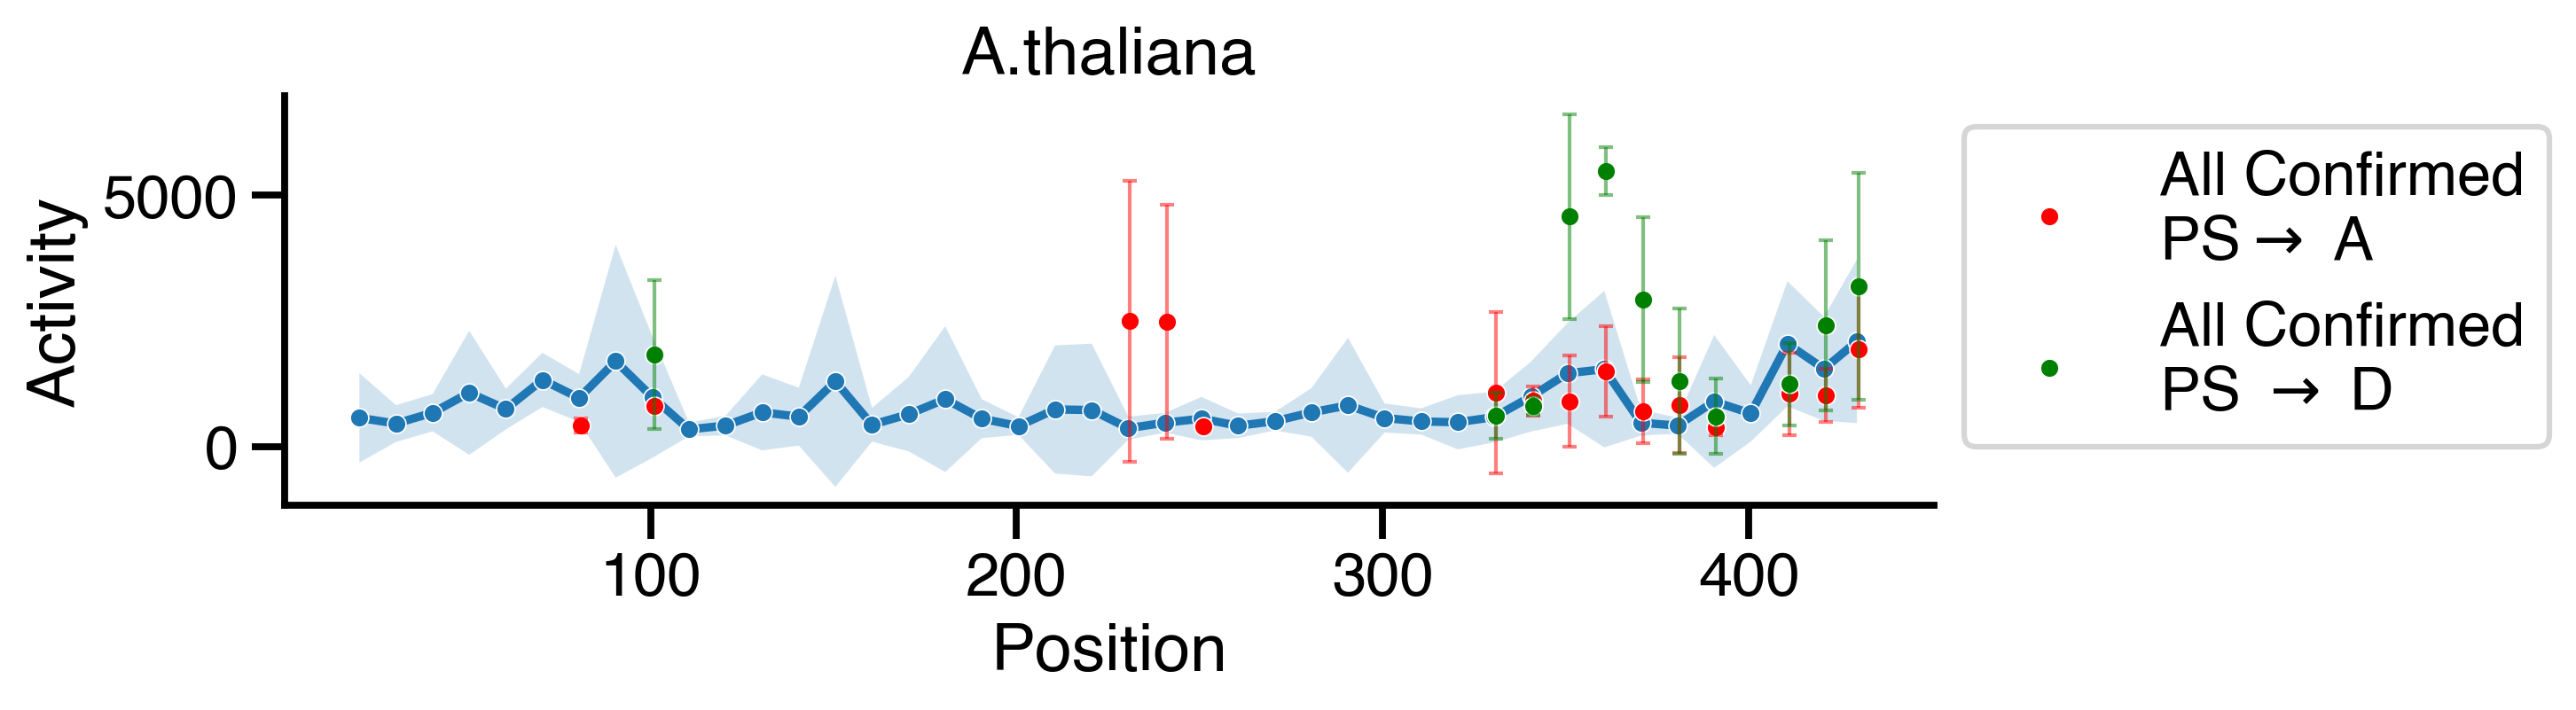

In [56]:
plot_full_PSv("BasicArTh")

BasicAmTr


,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,mid
0,1,40,BasicAmTr.1,Amborellatrichopoda_W1NK30_TAIR,MVTQDWPGLPRGVKFDPSDQELLGHLAAKVGVDGAKLHPF,4794.0,304.593235,NaN,1.0,NaN,NaN,20.5
1,11,50,BasicAmTr.2,Amborellatrichopoda_W1NK30_TAIR,RGVKFDPSDQELLGHLAAKVGVDGAKLHPFIDEFIMTLYE,NaN,NaN,NaN,NaN,NaN,NaN,30.5
2,21,60,BasicAmTr.3,Amborellatrichopoda_W1NK30_TAIR,ELLGHLAAKVGVDGAKLHPFIDEFIMTLYEEDGICYTHPQ,2143.0,772.465619,NaN,1.0,NaN,NaN,40.5
3,31,70,BasicAmTr.4,Amborellatrichopoda_W1NK30_TAIR,GVDGAKLHPFIDEFIMTLYEEDGICYTHPQKLPGVKQDGS,2949.0,915.831820,NaN,1.0,NaN,NaN,50.5
4,41,80,BasicAmTr.5,Amborellatrichopoda_W1NK30_TAIR,IDEFIMTLYEEDGICYTHPQKLPGVKQDGSVCHFFHRTVK,NaN,NaN,NaN,NaN,NaN,NaN,60.5
5,51,90,BasicAmTr.6,Amborellatrichopoda_W1NK30_TAIR,EDGICYTHPQKLPGVKQDGSVCHFFHRTVKAYNSGTRKRR,NaN,NaN,NaN,NaN,NaN,NaN,70.5
6,61,100,BasicAmTr.7,Amborellatrichopoda_W1NK30_TAIR,KLPGVKQDGSVCHFFHRTVKAYNSGTRKRRKILNHLNPCS,NaN,NaN,NaN,NaN,NaN,NaN,80.5
7,71,110,BasicAmTr.8,Amborellatrichopoda_W1NK30_TAIR,VCHFFHRTVKAYNSGTRKRRKILNHLNPCSGDVRWHKTGK,6489.0,817.005794,NaN,1.0,NaN,NaN,90.5
8,81,120,BasicAmTr.9,Amborellatrichopoda_W1NK30_TAIR,AYNSGTRKRRKILNHLNPCSGDVRWHKTGKTRQVIVDGVH,NaN,NaN,NaN,NaN,NaN,NaN,100.5
9,91,130,BasicAmTr.10,Amborellatrichopoda_W1NK30_TAIR,KILNHLNPCSGDVRWHKTGKTRQVIVDGVHRGCKKIMVLY,NaN,NaN,NaN,NaN,NaN,NaN,110.5


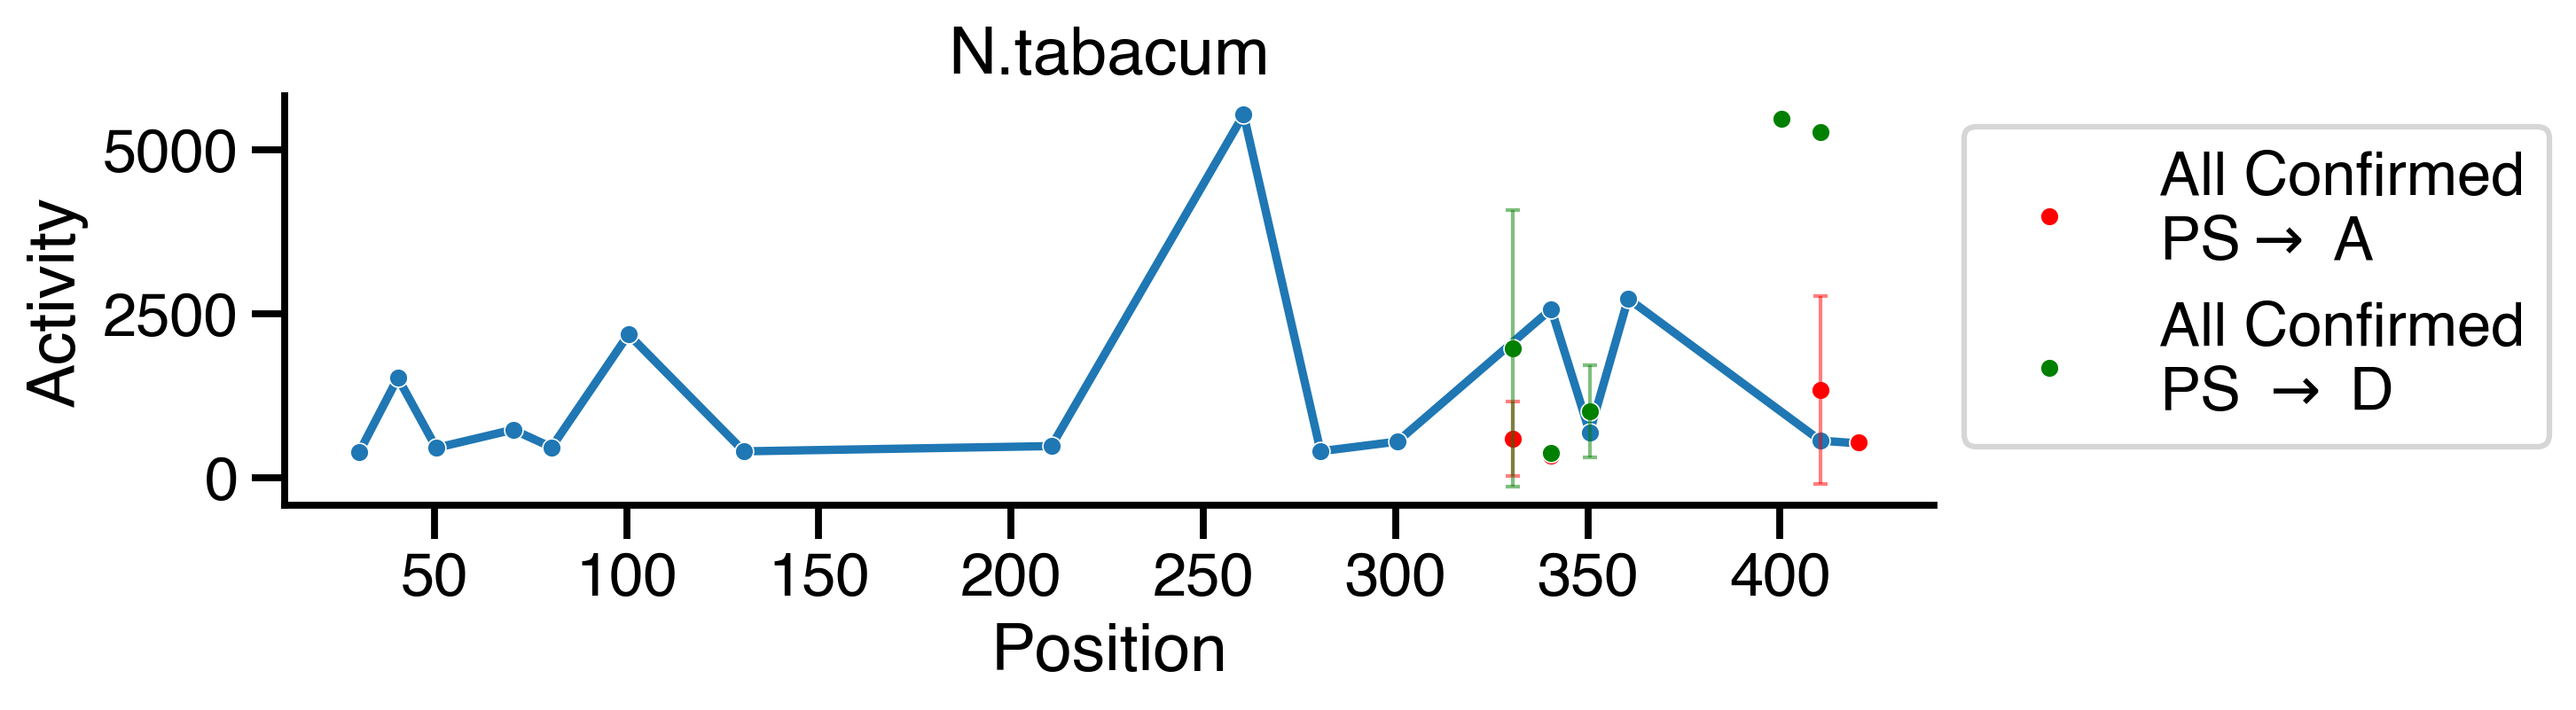

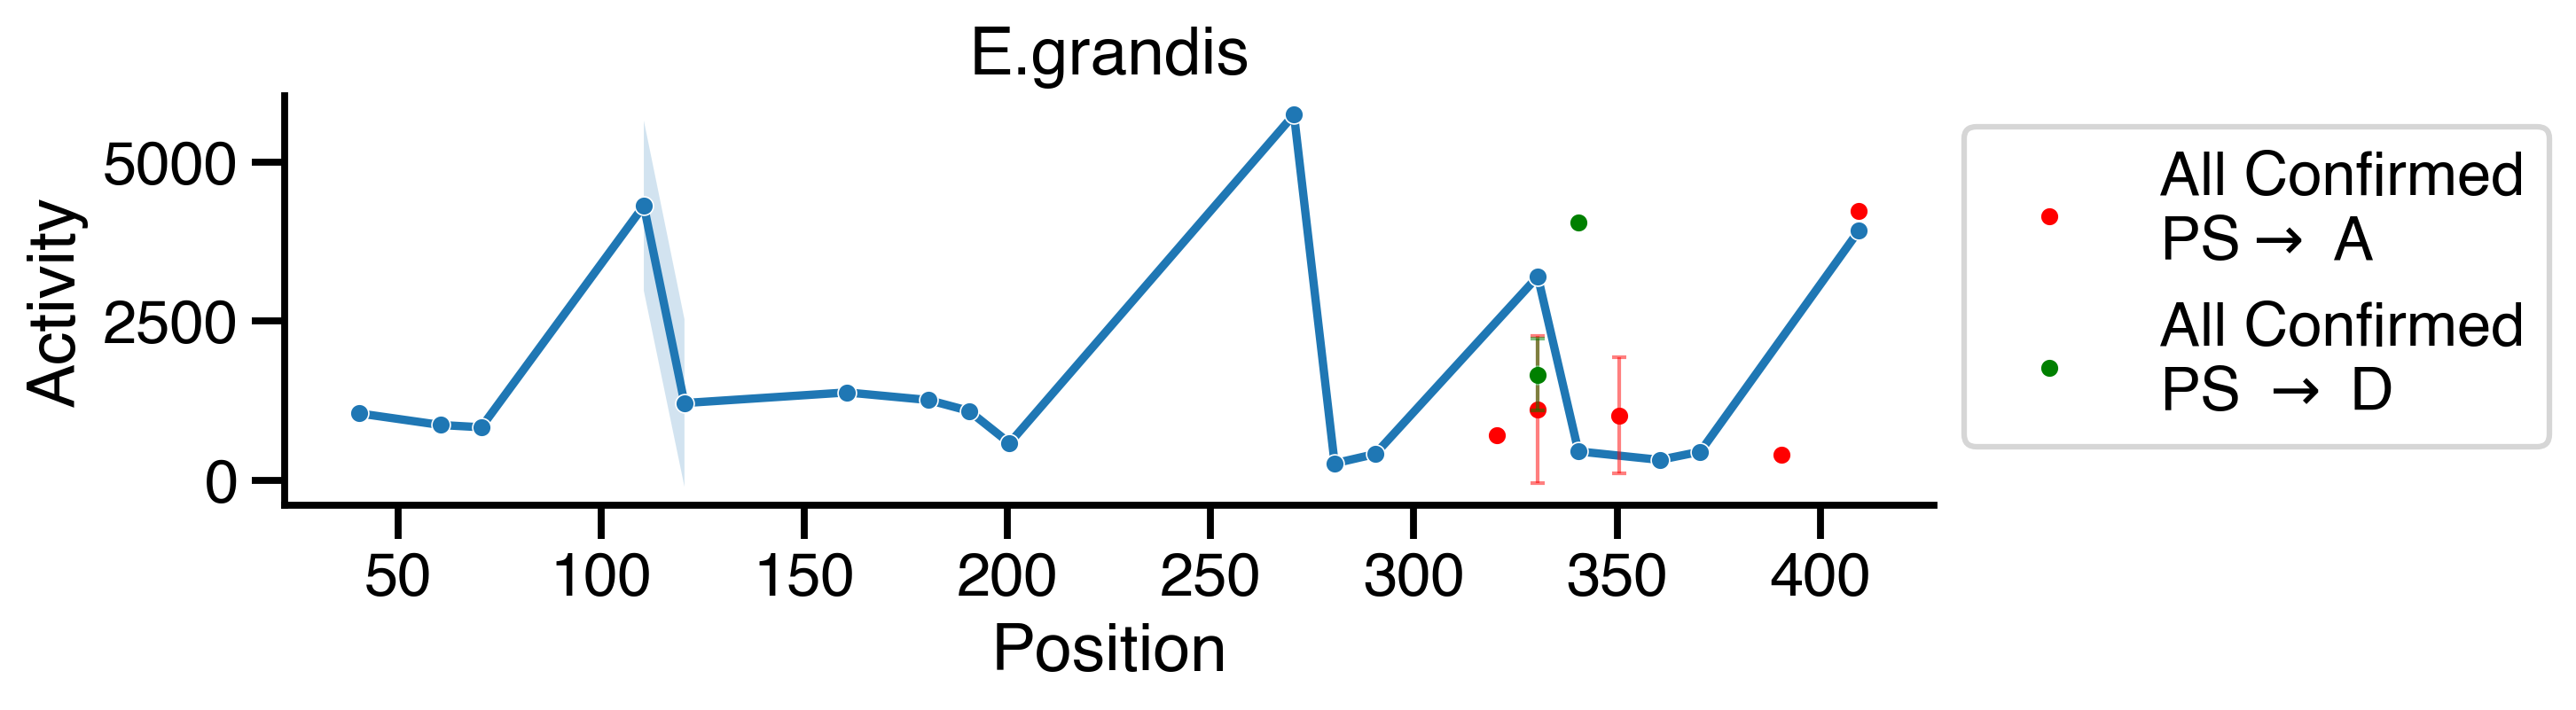

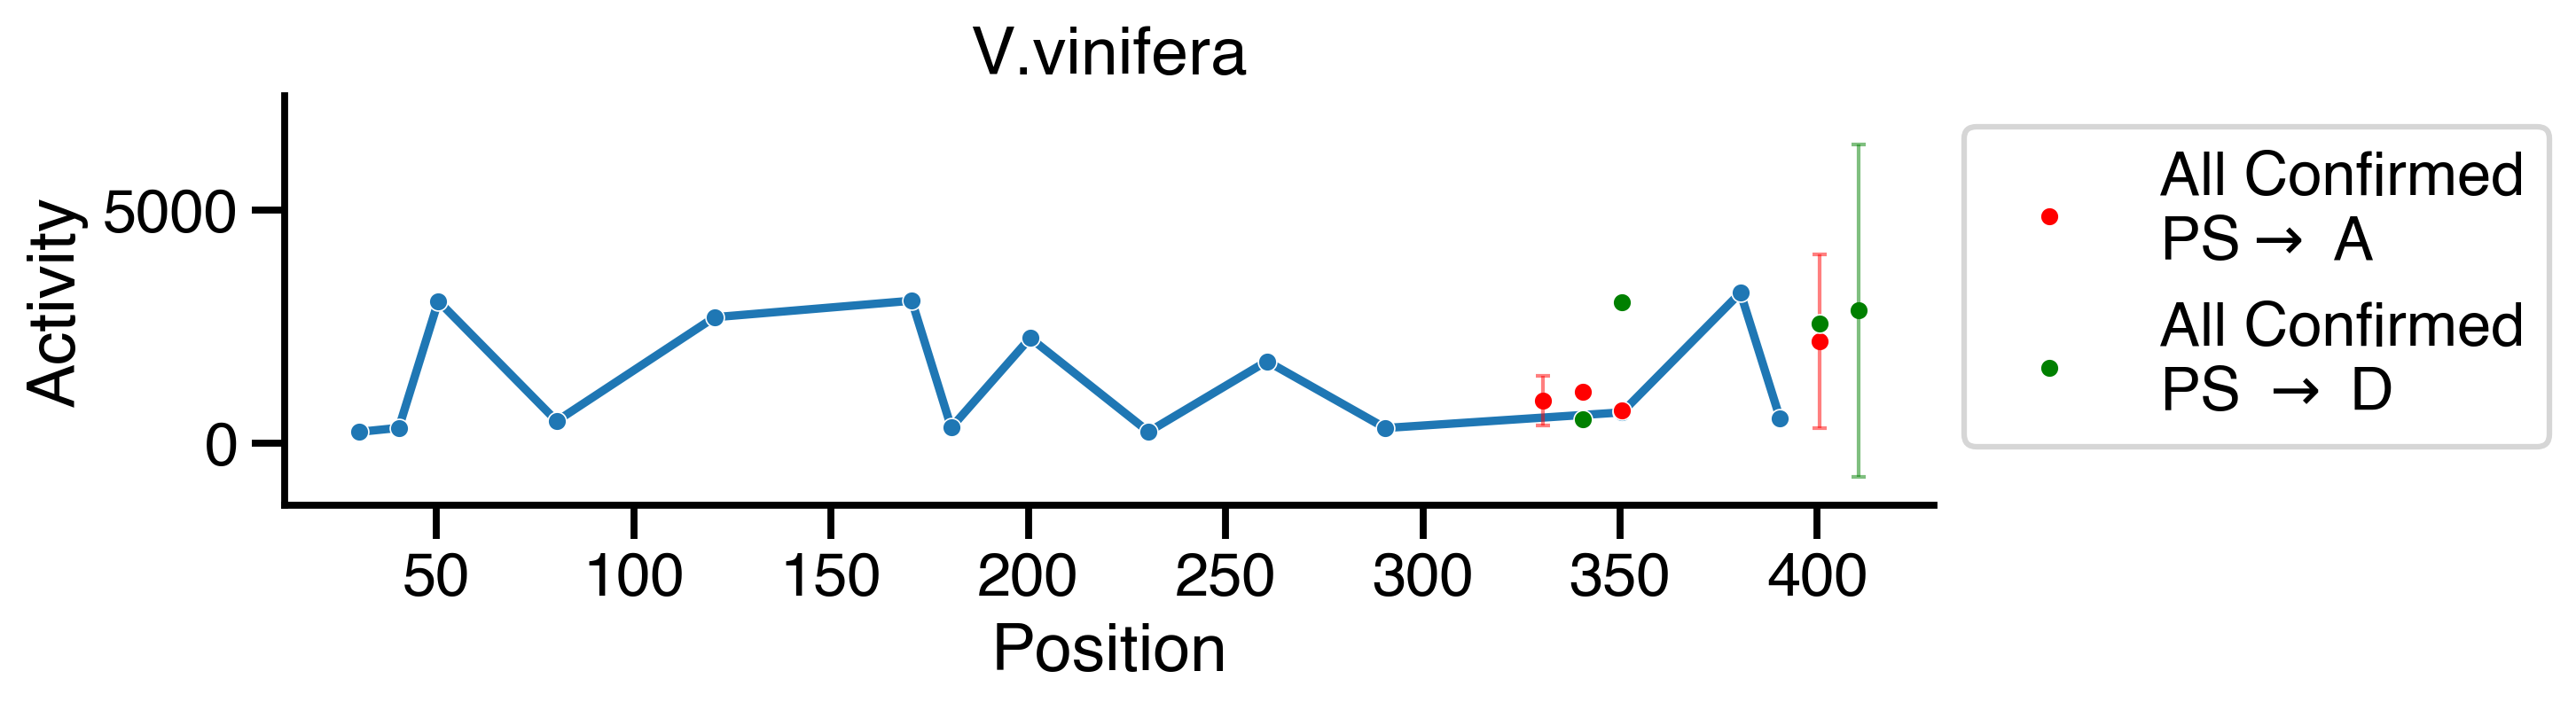

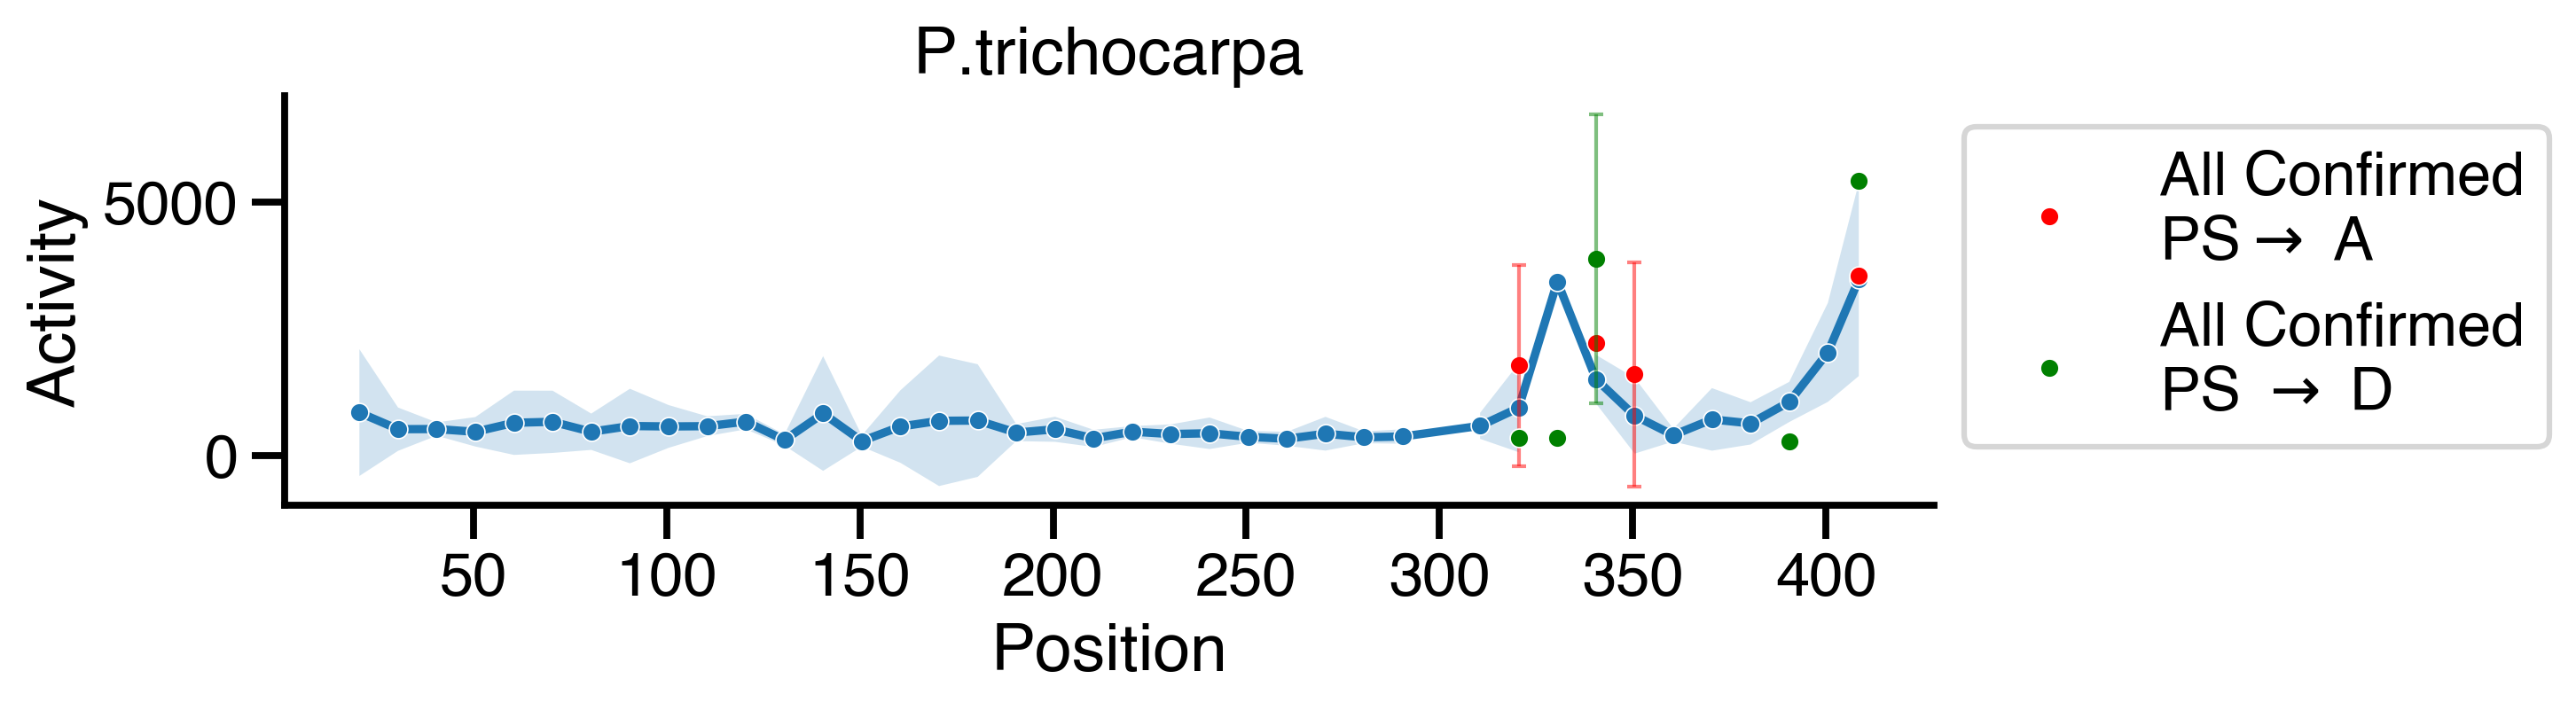

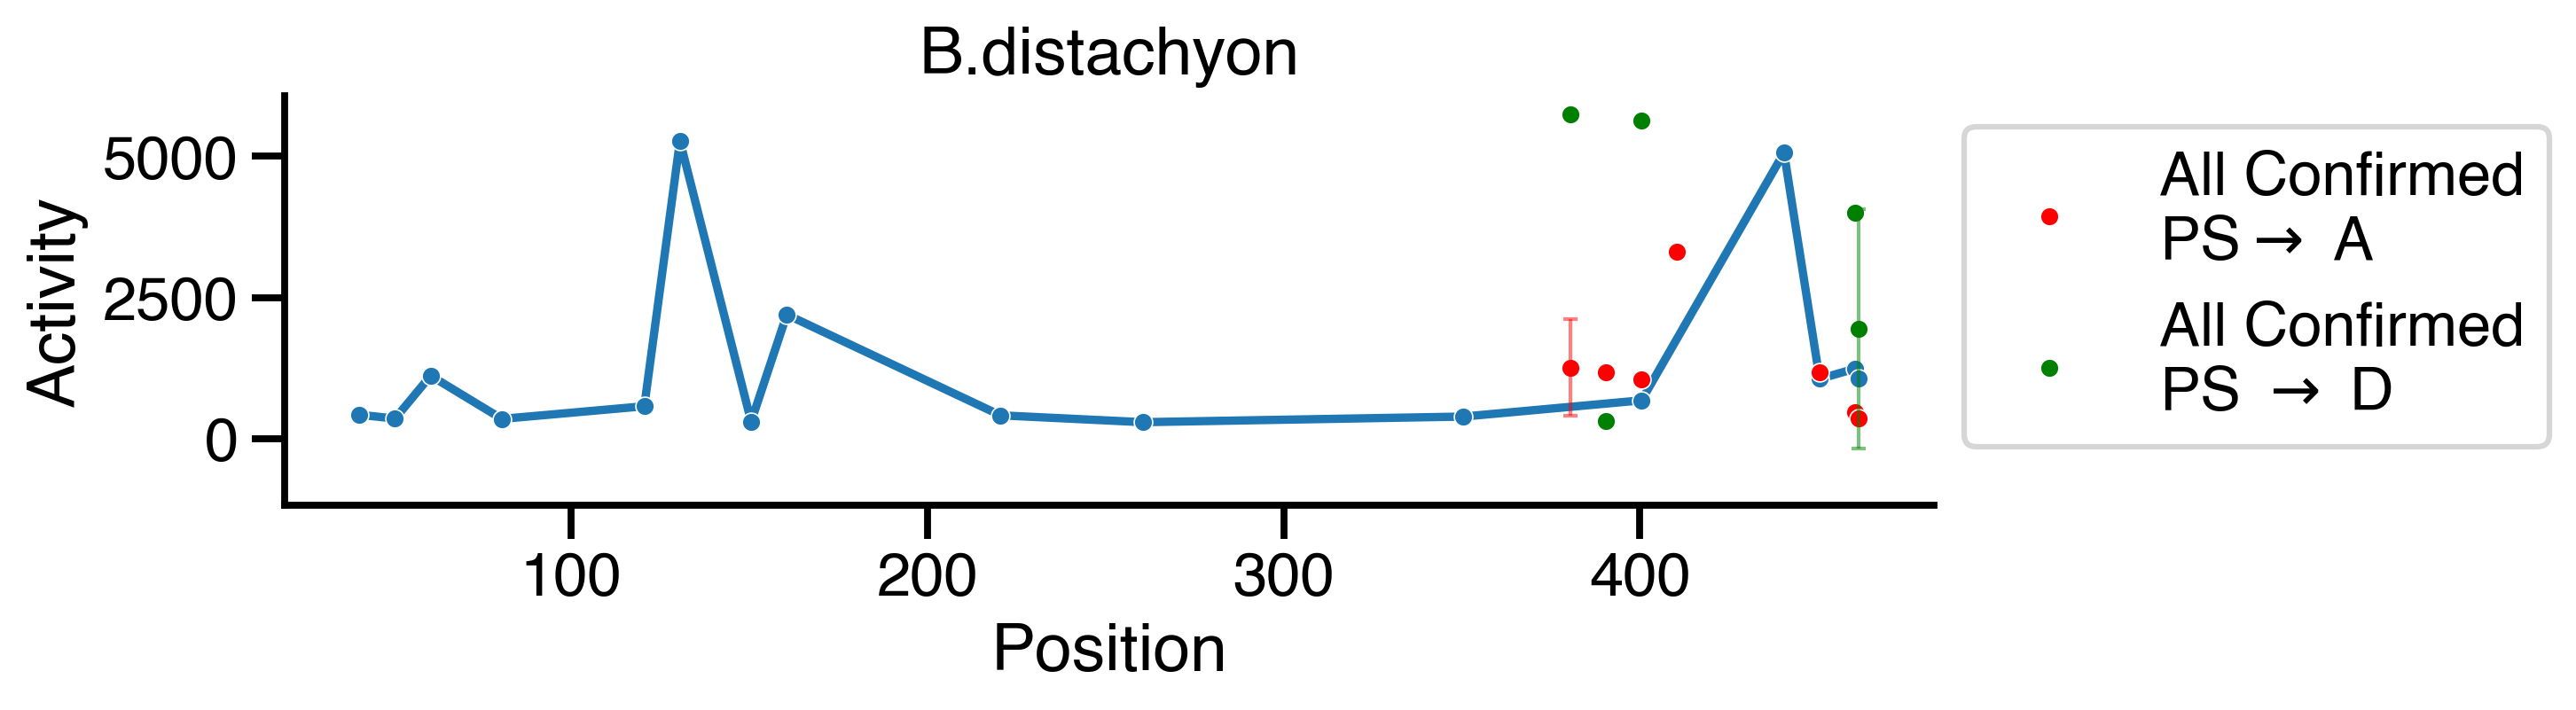

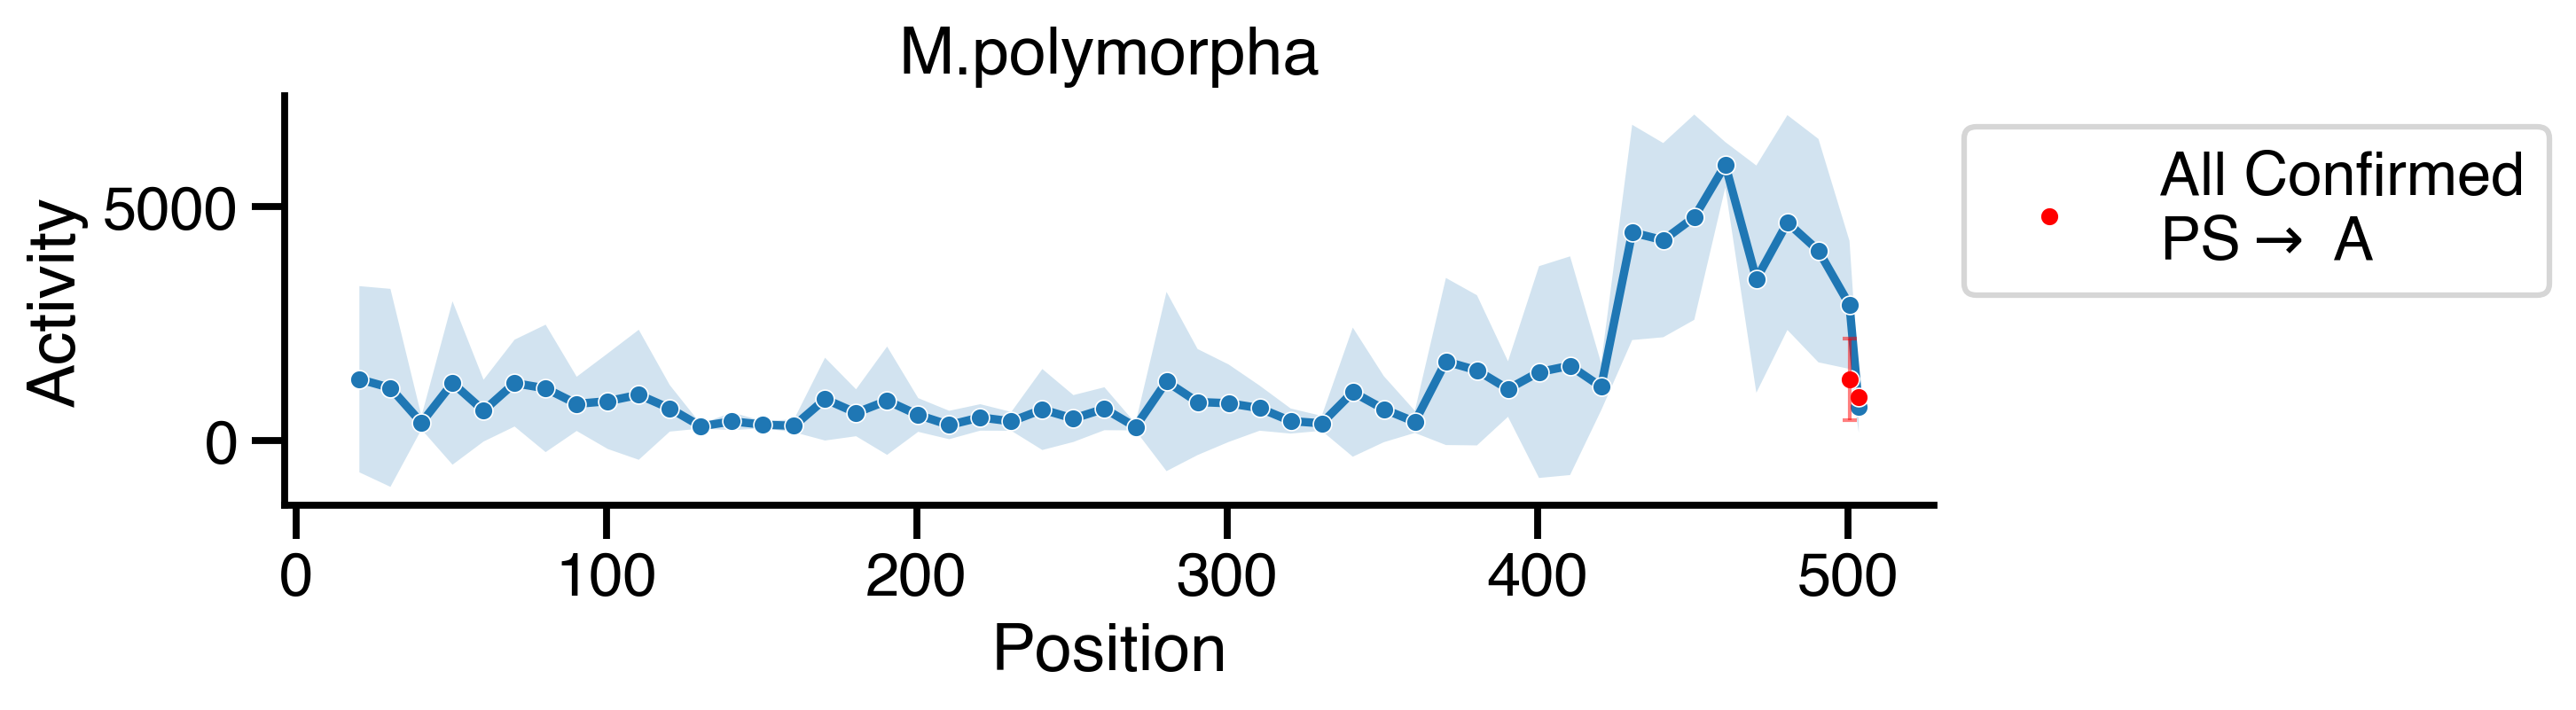

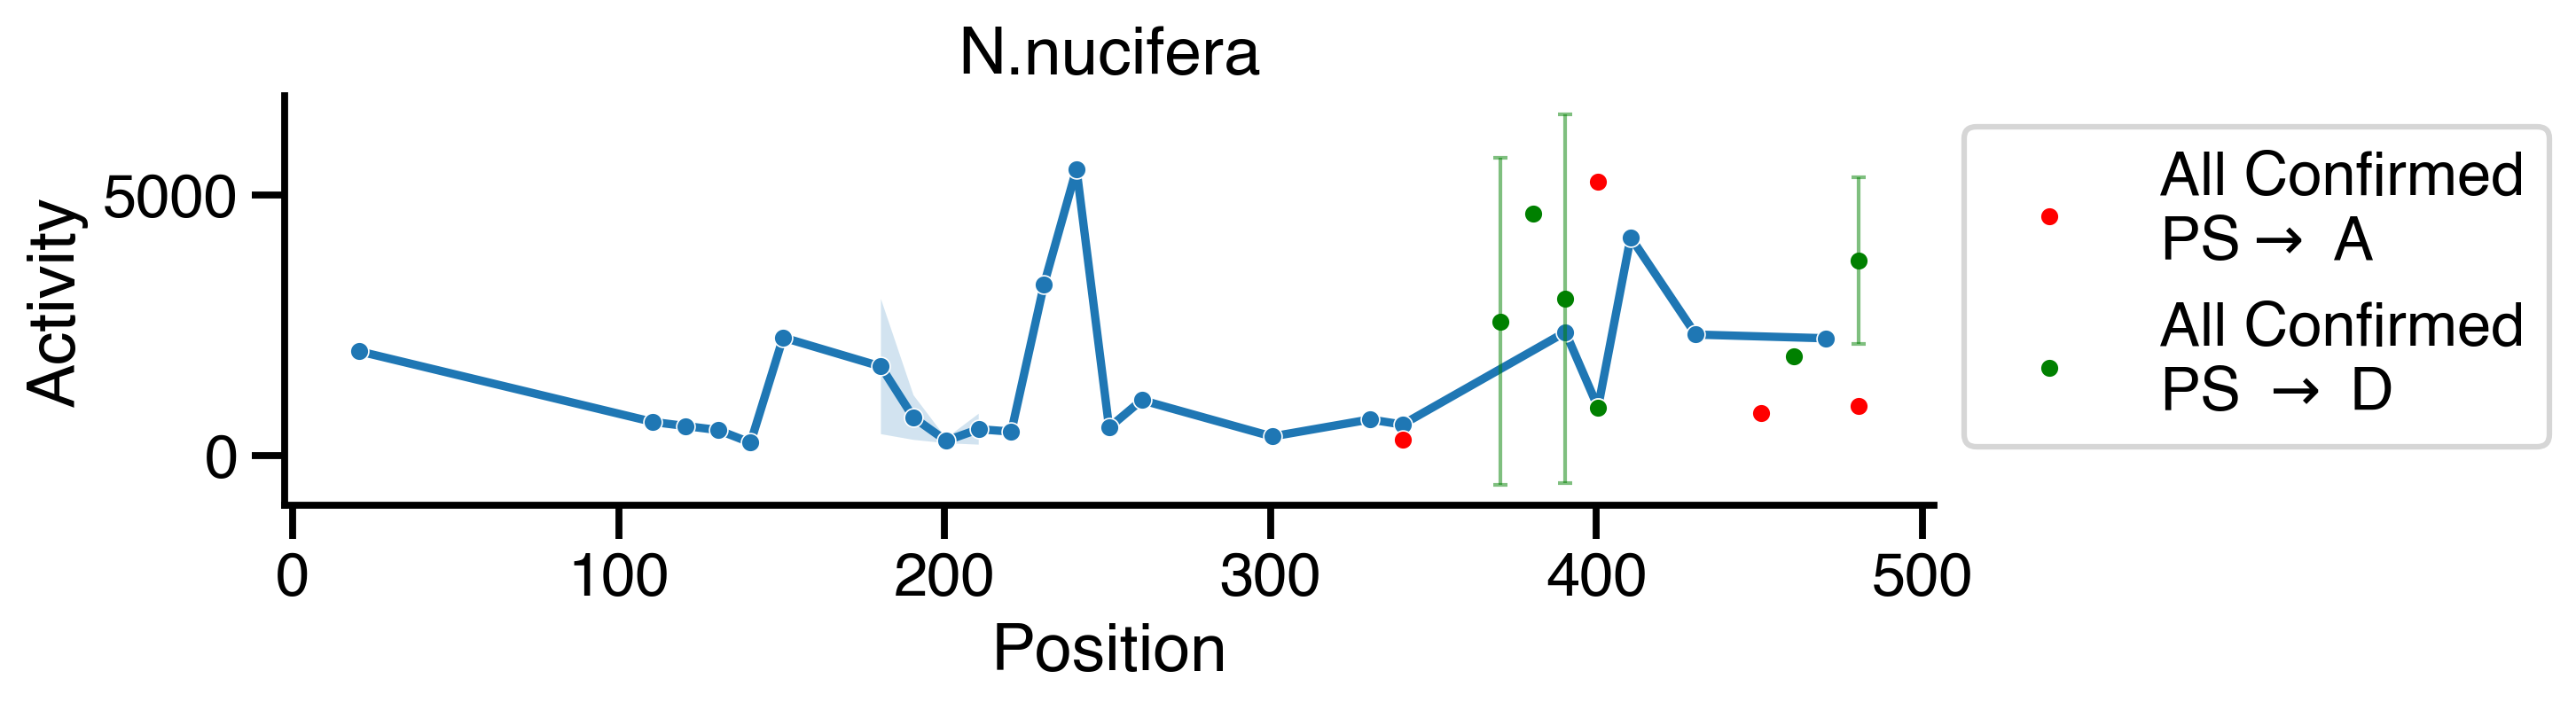

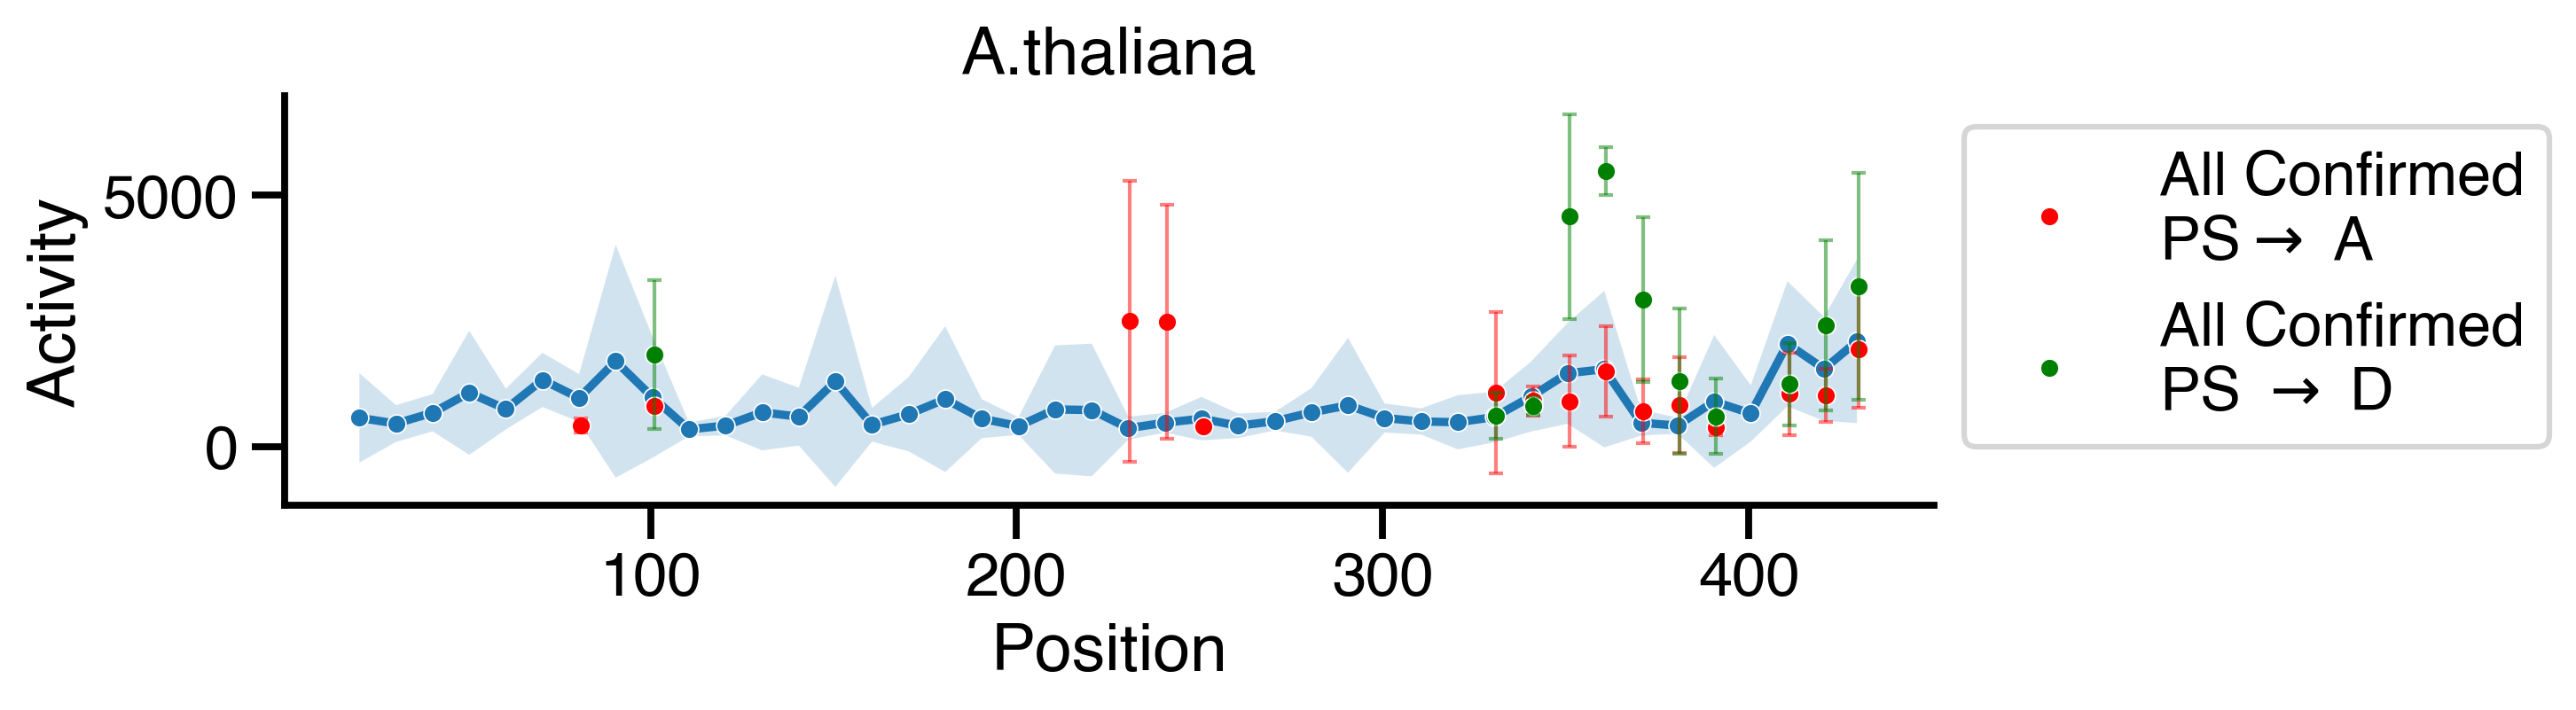

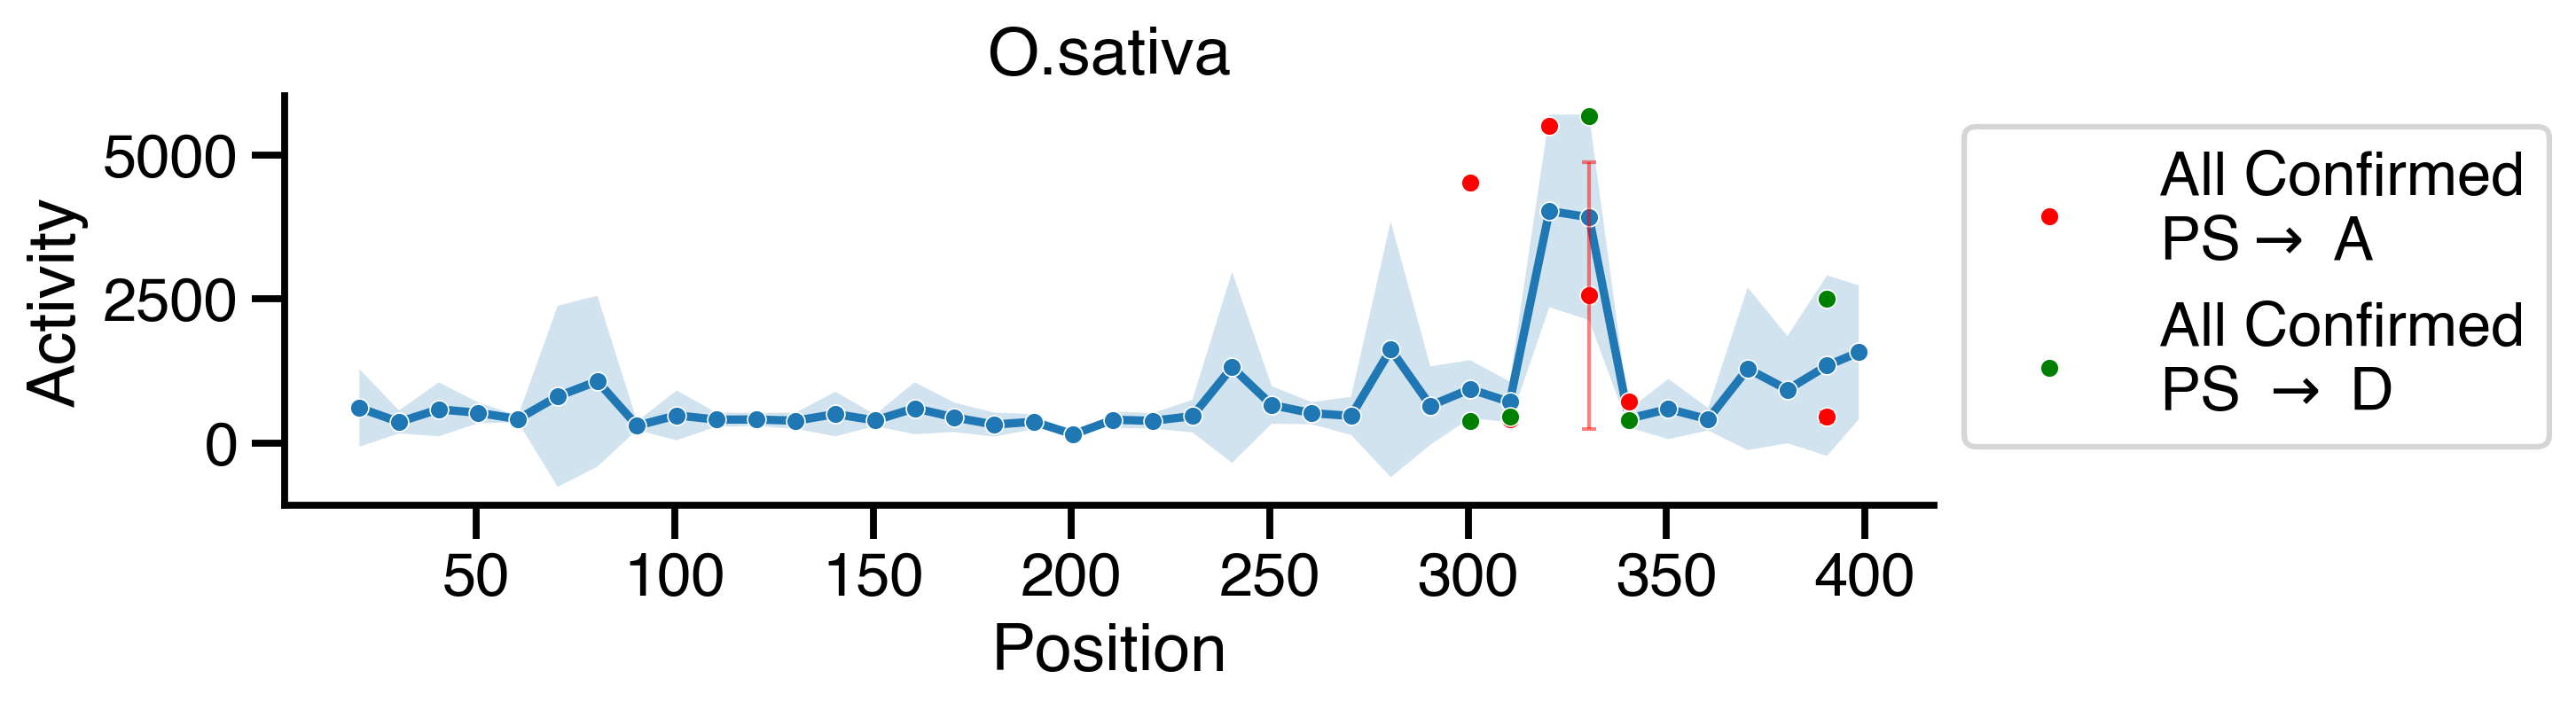

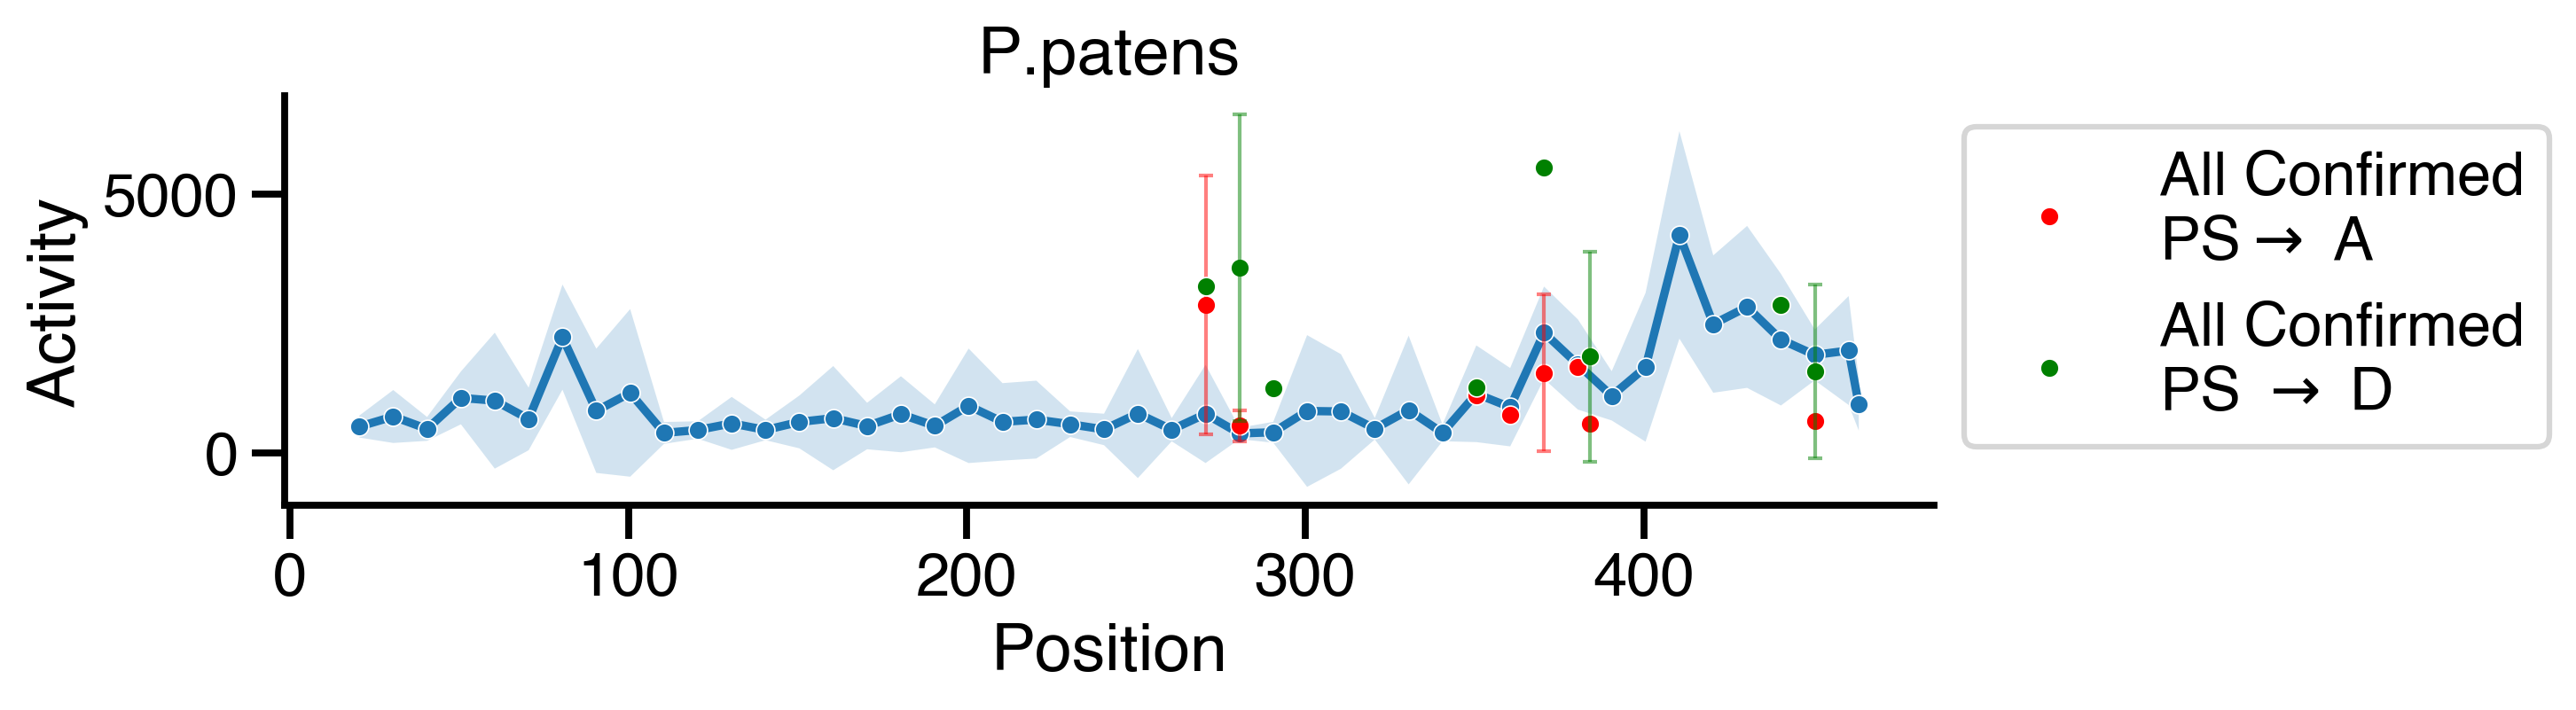

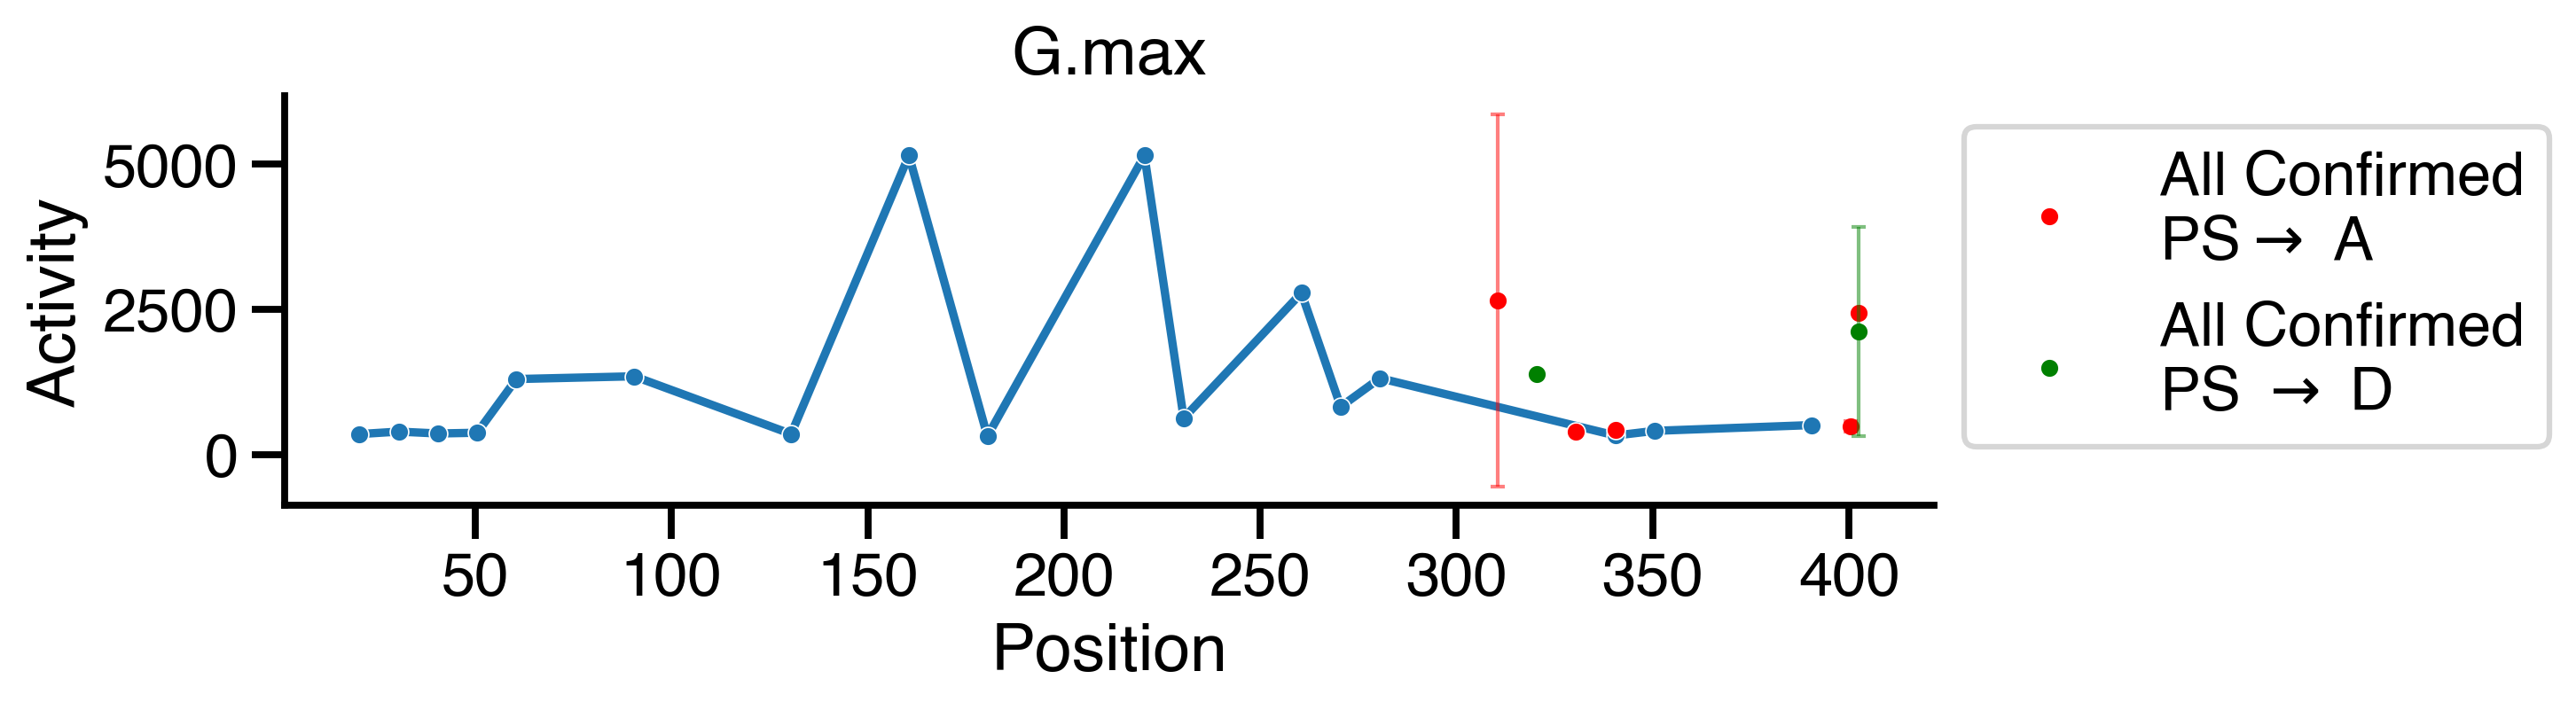

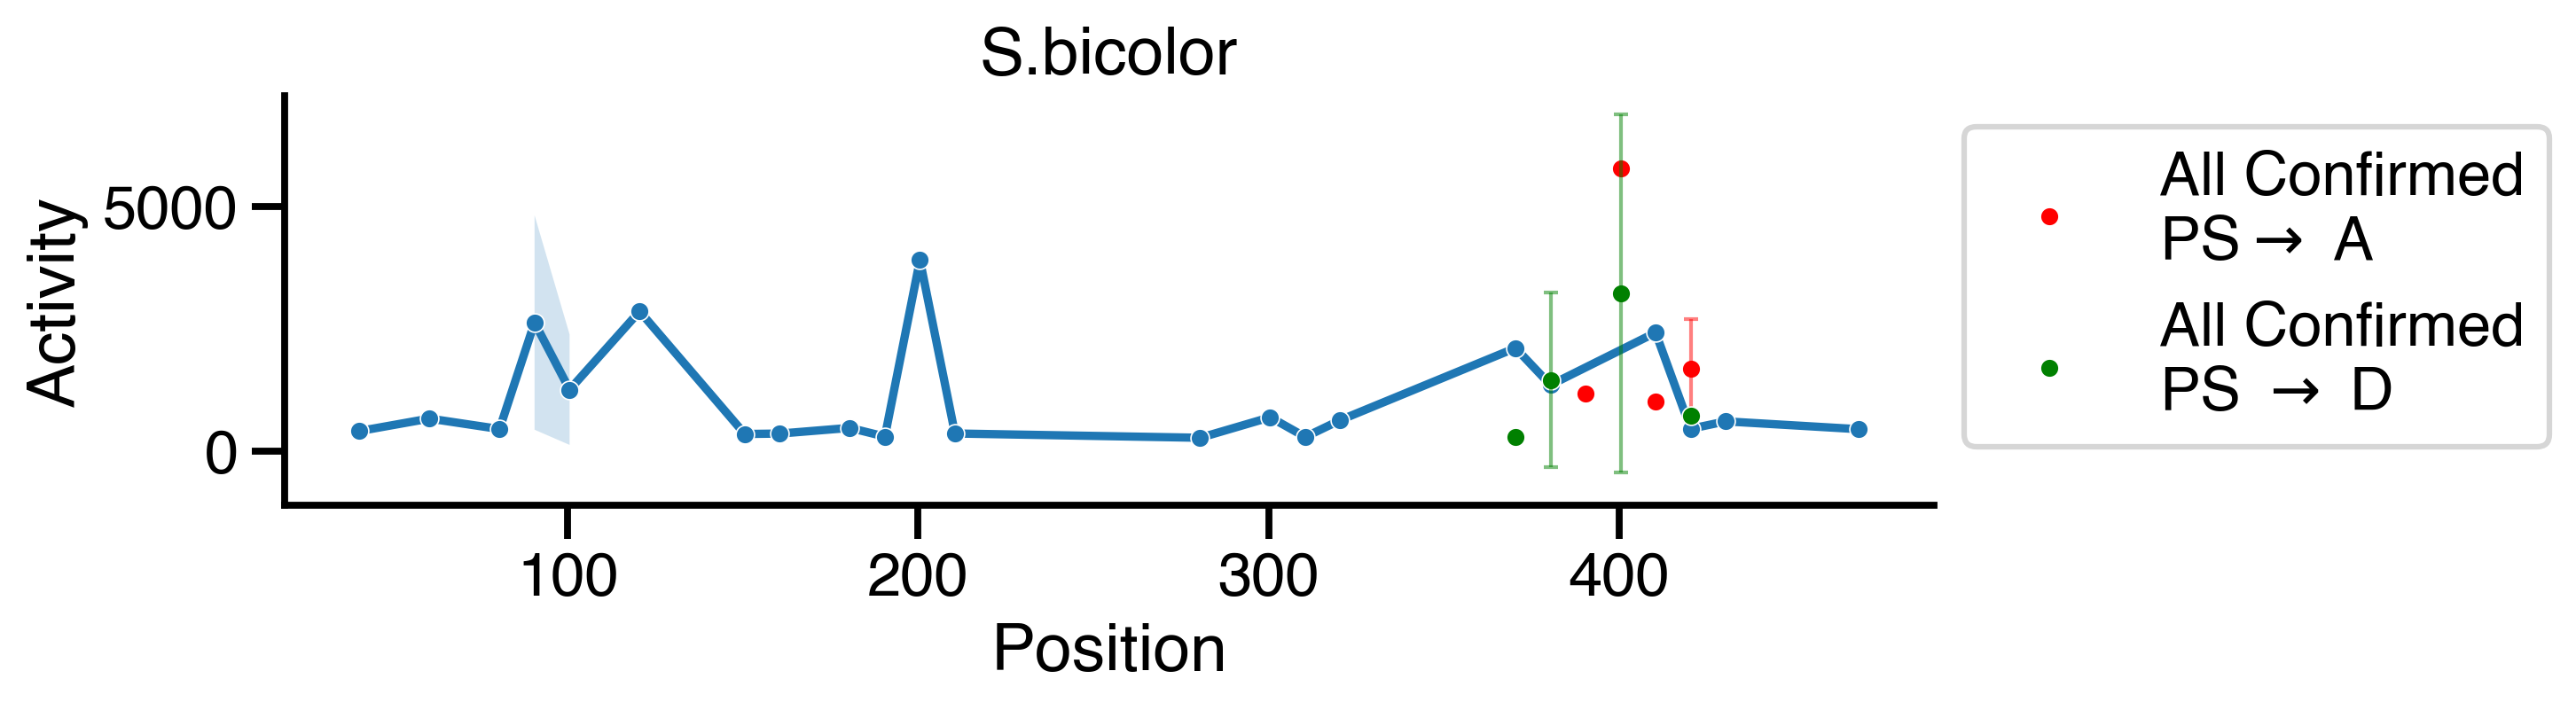

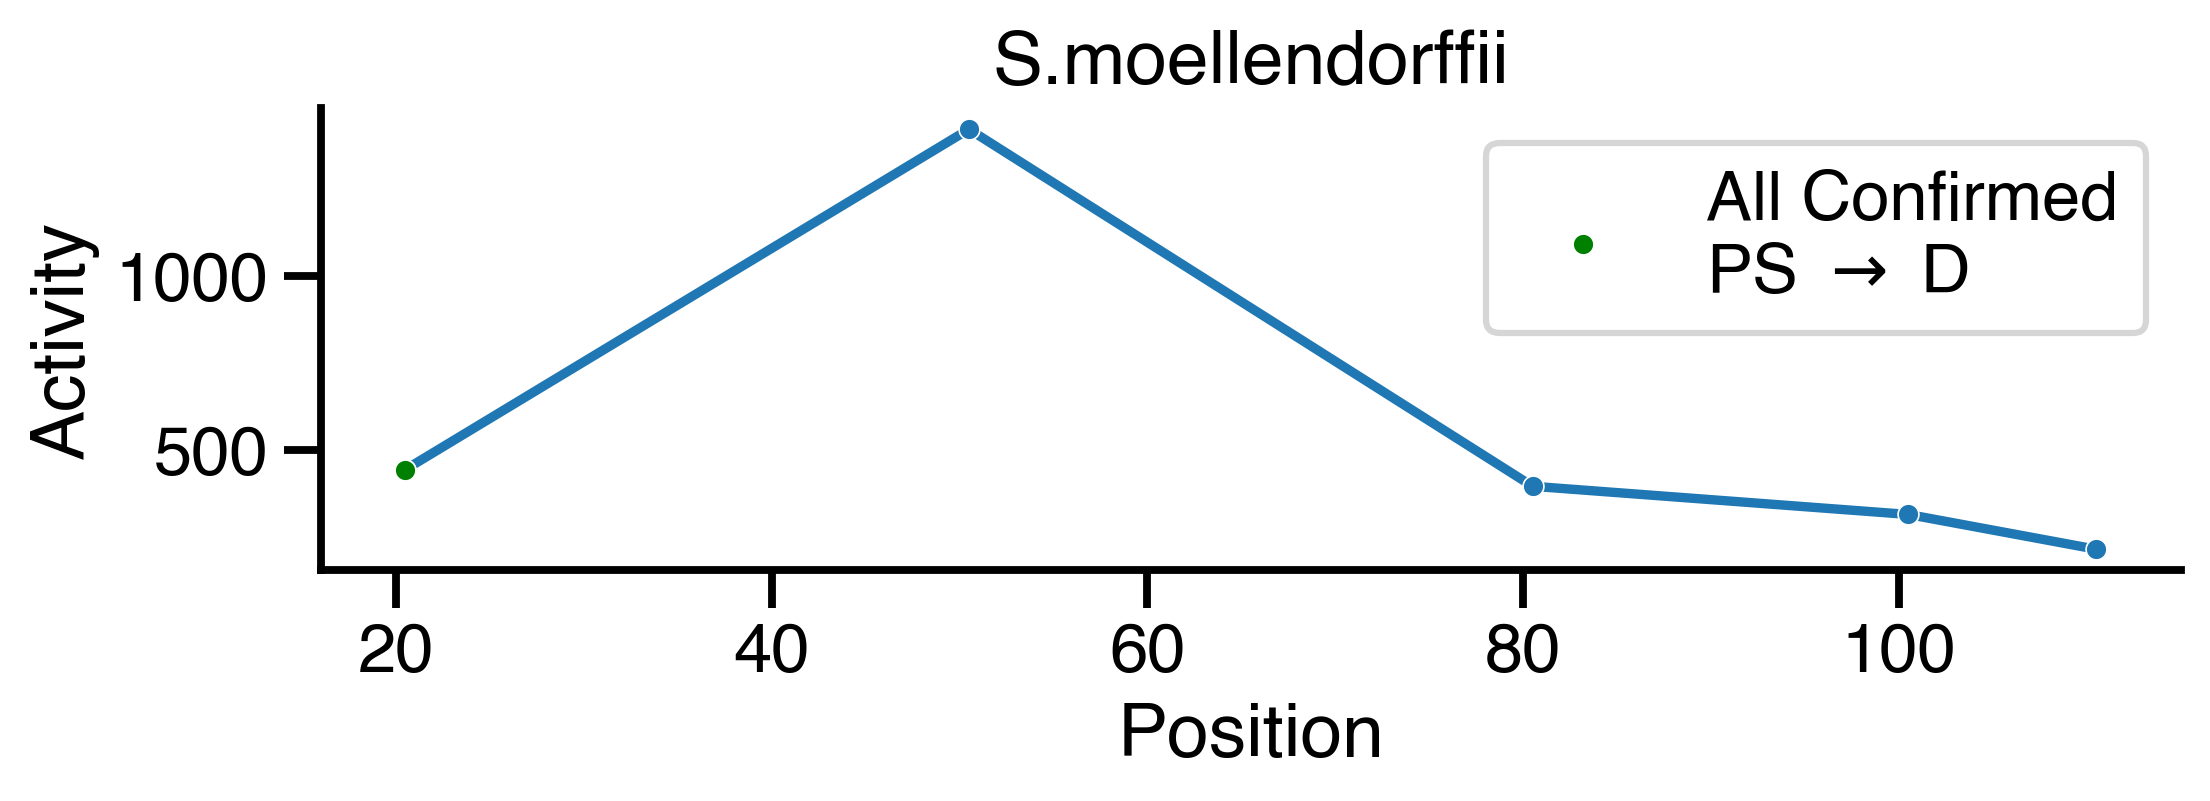

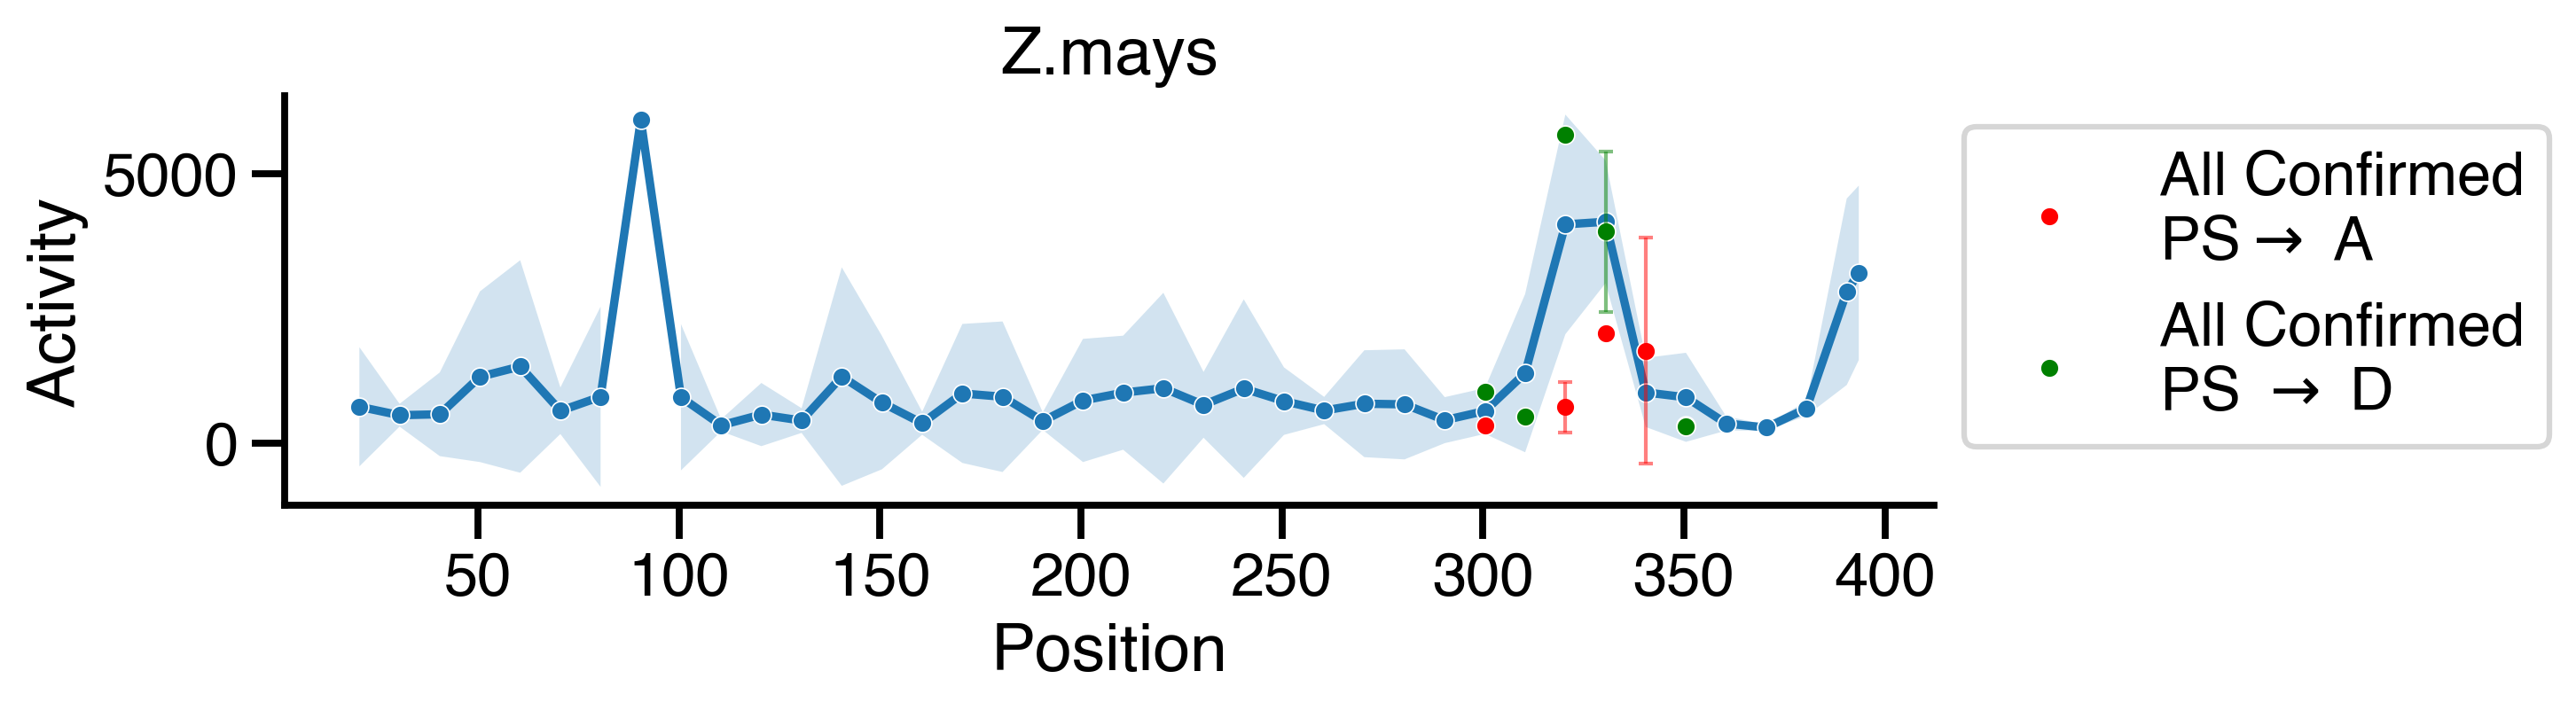

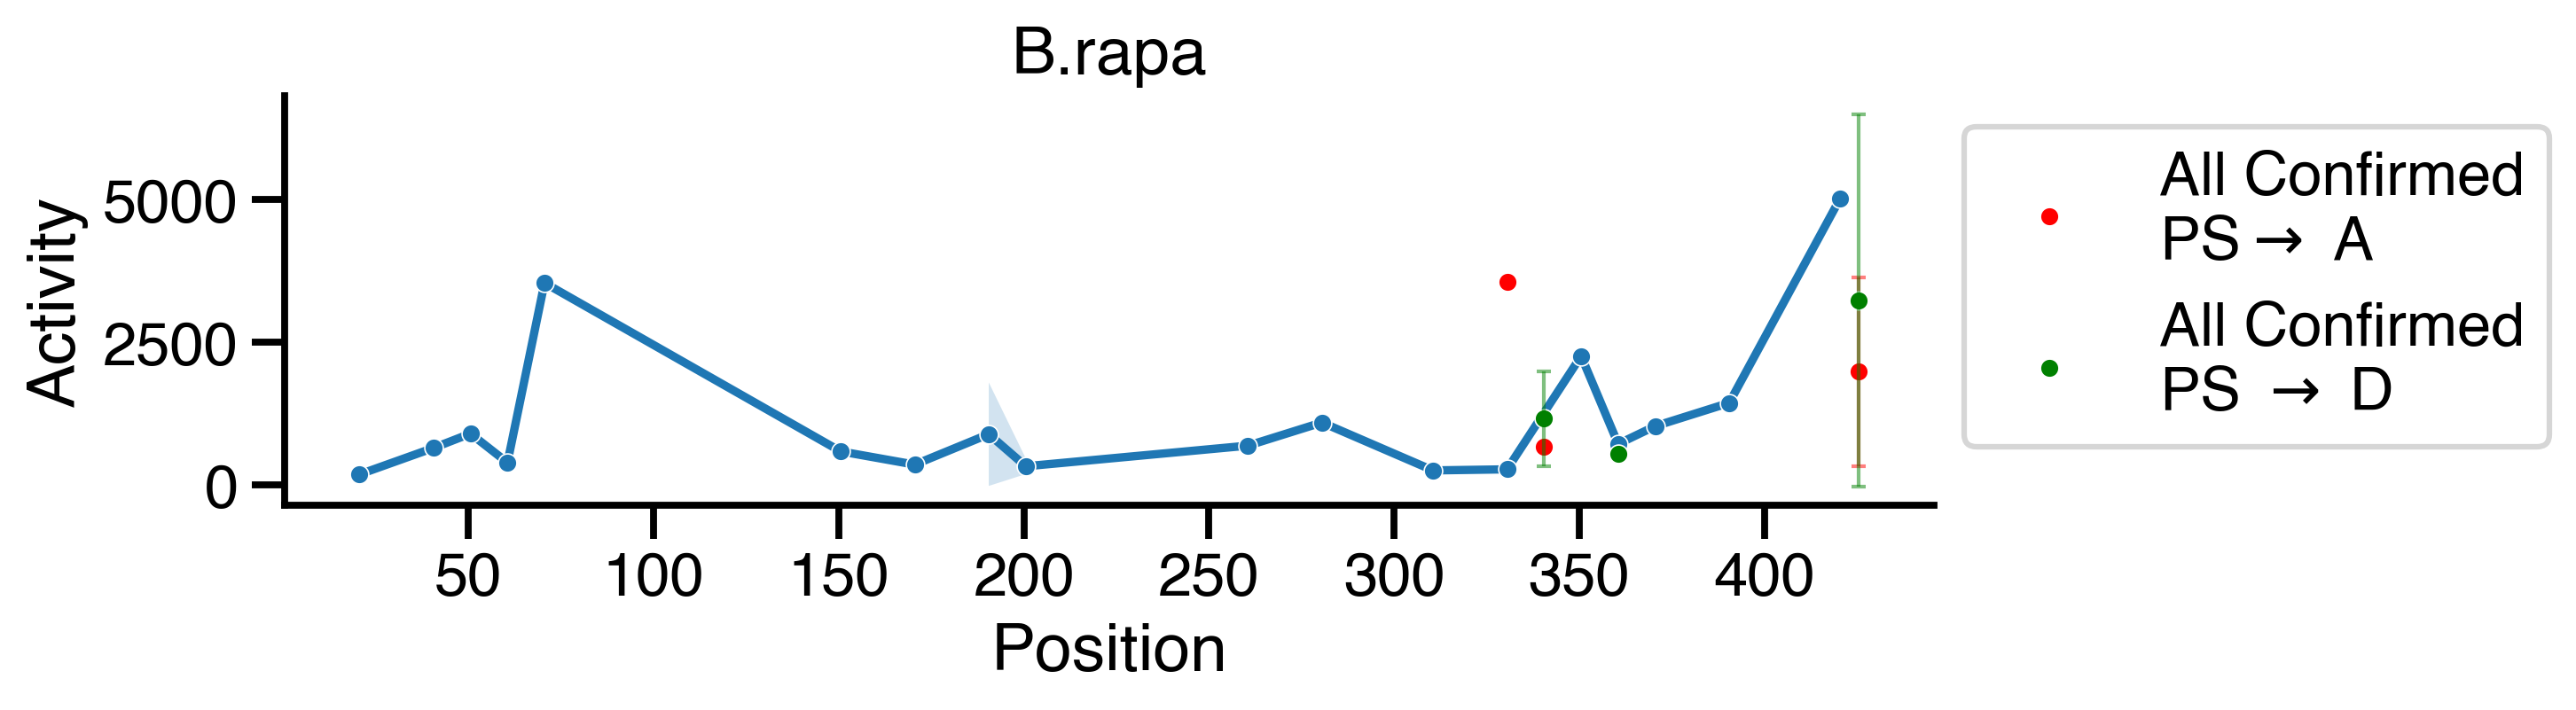

In [57]:
for description_name in set(ortholog_tiles["Description_name"]):
    plot_full_PSv(description_name)

# 2. Single PSvar figures

Requested for NAC44, NAC085, P.trichocarpa, M.polymorpha, Z.mays, A. Thaliana, P53.

In [280]:
def plot_single_PSv(description_name, title = description_name):
    ## Getting data
    # Get all vars with that description name
    description_name_vars = sog1_helpers.return_activities(description_name, pos_regex = "")
    description_name_vars["mid"] = (description_name_vars["Start"].astype(int) + description_name_vars["End"].astype(int)) / 2
    description_name_vars["mid"] = description_name_vars["mid"].astype(int)  + 1

    # Filter to WT tiles
    wt_tiles = description_name_vars[~description_name_vars["Description"].str.contains("_")]
    
    # Filter to PSv
    PS_mim = description_name_vars[description_name_vars["Description"].str.contains("SingleD")]
    PS_mut = description_name_vars[description_name_vars["Description"].str.contains("SingleA")]
    
    if description_name == "BasicSeMo":
        PS_mim =  description_name_vars[description_name_vars["Description"].str.contains("SingleD")]
        PS_mut =  description_name_vars[description_name_vars["Description"].str.contains("SingleA")]
    
    if description_name == "BasicArTh":
        PS_mim =  sog1_helpers.return_activities("PSv_conf2sD")
        PS_mim = PS_mim[~PS_mim["Description"].str.contains("DD")]
        PS_mut =  sog1_helpers.return_activities("PSv_conf2sA_STYA")

    if len(PS_mim) == 0:
        print(description_name)
        display(description_name_vars)
    
    # Compare to wt

    PS_mim_vs_wt = sog1_helpers.add_var_positions(PS_mim, wt_tiles, "Activity_S3_1")
    PS_mut_vs_wt = sog1_helpers.add_var_positions(PS_mut, wt_tiles, "Activity_S3_1")
    
    # Get average log activity fold change
    conf_s_A_D = pd.merge(PS_mut_vs_wt, PS_mim_vs_wt, on = ["Start", "mid", "End", "var"], suffixes = ("_A", "_D"))
    conf_s_A_D["log_activ_fold_change_D"] = np.log(conf_s_A_D["activ_fold_change_D"])
    conf_s_A_D["log_activ_fold_change_A"] = np.log(conf_s_A_D["activ_fold_change_A"])
    pos_avgs = conf_s_A_D[["var", "log_activ_fold_change_D", "log_activ_fold_change_A"]].groupby("var").mean()
    pos_avgs = pos_avgs.reset_index()
    
    #display(conf_s_A_D)
    
    ## Plotting

    sns.set_context('talk')
    fig, axs = plt.subplots(2, 1, figsize=(8,5), sharex=True, gridspec_kw = {'height_ratios' : [1, 2]}, dpi = 300)

    sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_A", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "red", width = 0.25)
    sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_D", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "green", width = 0.25)
    sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_A", color = "red", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                    label = "Phosphomutants", alpha = 0.85)
    sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_D", color = "green", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                    label = "Phosphomimetics", alpha = 0.85)
    axs[0].legend(fontsize = "x-small", framealpha = 1, bbox_to_anchor = (1,1))

    # Plot part 2
    axs[1].axhline(0, color = 'black', zorder = -1)
    sog1_helpers.plot_all_tiles(PS_mut_vs_wt, "Activity_S3_1" + "_var", ax=axs[1], color='silver')
    sns.scatterplot(data=PS_mut_vs_wt, 
                    x="var", 
                    y="Activity_S3_1" + "_var", 
                    color="red", 
                    legend=False, 
                    alpha=0.7, ax=axs[1], marker = "D", edgecolor = "none", s = 10)
    axs[1].errorbar(PS_mut_vs_wt["mid"], 
                PS_mut_vs_wt["Activity_S3_1_var"], 
                yerr=[PS_mut_vs_wt["Error_var"], PS_mut_vs_wt["Error_var"]], 
                fmt='none', 
                ecolor='silver', 
                elinewidth=1, 
                capsize=2, 
                zorder = 2, alpha = 0.5)


    sog1_helpers.plot_all_tiles(PS_mim_vs_wt, "Activity_S3_1" + "_var", ax=axs[1], color='silver')
    sns.scatterplot(data=PS_mim_vs_wt, 
                    x="var", 
                    y="Activity_S3_1" + "_var", 
                    color="green", 
                    legend=False, 
                    alpha=0.7, ax=axs[1], marker = "D", edgecolor = "none", s = 10)
    axs[1].errorbar(PS_mim_vs_wt["mid"], 
                PS_mim_vs_wt["Activity_S3_1_var"], 
                yerr=[PS_mim_vs_wt["Error_var"], PS_mim_vs_wt["Error_var"]], 
                fmt='none', 
                ecolor='silver', 
                elinewidth=1, 
                capsize=2, 
                zorder = 2, alpha = 0.5)

    sns.lineplot(data=wt_tiles, x="mid", y="Activity_S3_1", label="WT Tiles", lw=2, ax=axs[1], legend = False)
    axs[1].fill_between(wt_tiles["mid"], wt_tiles["activ_err_start"],  wt_tiles["activ_err_end"], alpha=0.2)


    #axs[0].axhline(0, color = "gray", zorder = 0, linestyle = "--")
    axs[0].axhline(0, color = 'black', zorder = -1)
    axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, ha = 'center', labelpad = 65, va = 'center')
    
    ymin, ymax = np.nanmin(pos_avgs.drop(columns = 'var')), np.nanmax(pos_avgs.drop(columns = 'var'))
    extrema = max(np.abs(ymin), np.abs(ymax))
    #print(ymin, ymax)
    
    axs[0].set_ylim(-1 * extrema * 1.5, extrema * 1.5)

    #axs[1].set_xlim(1, 449)
    axs[1].set_ylabel("Activity", rotation = 0, ha = 'center', labelpad = 65, va = 'center')
    axs[1].set_xlabel("Position")

    #sns.despine()
    sns.despine(bottom = True)

    plt.suptitle(title + ": Single PSv")
    fig.align_ylabels(axs)
    plt.savefig("../output/figures/single_PS_impact/" + title + ".png", bbox_inches = 'tight')



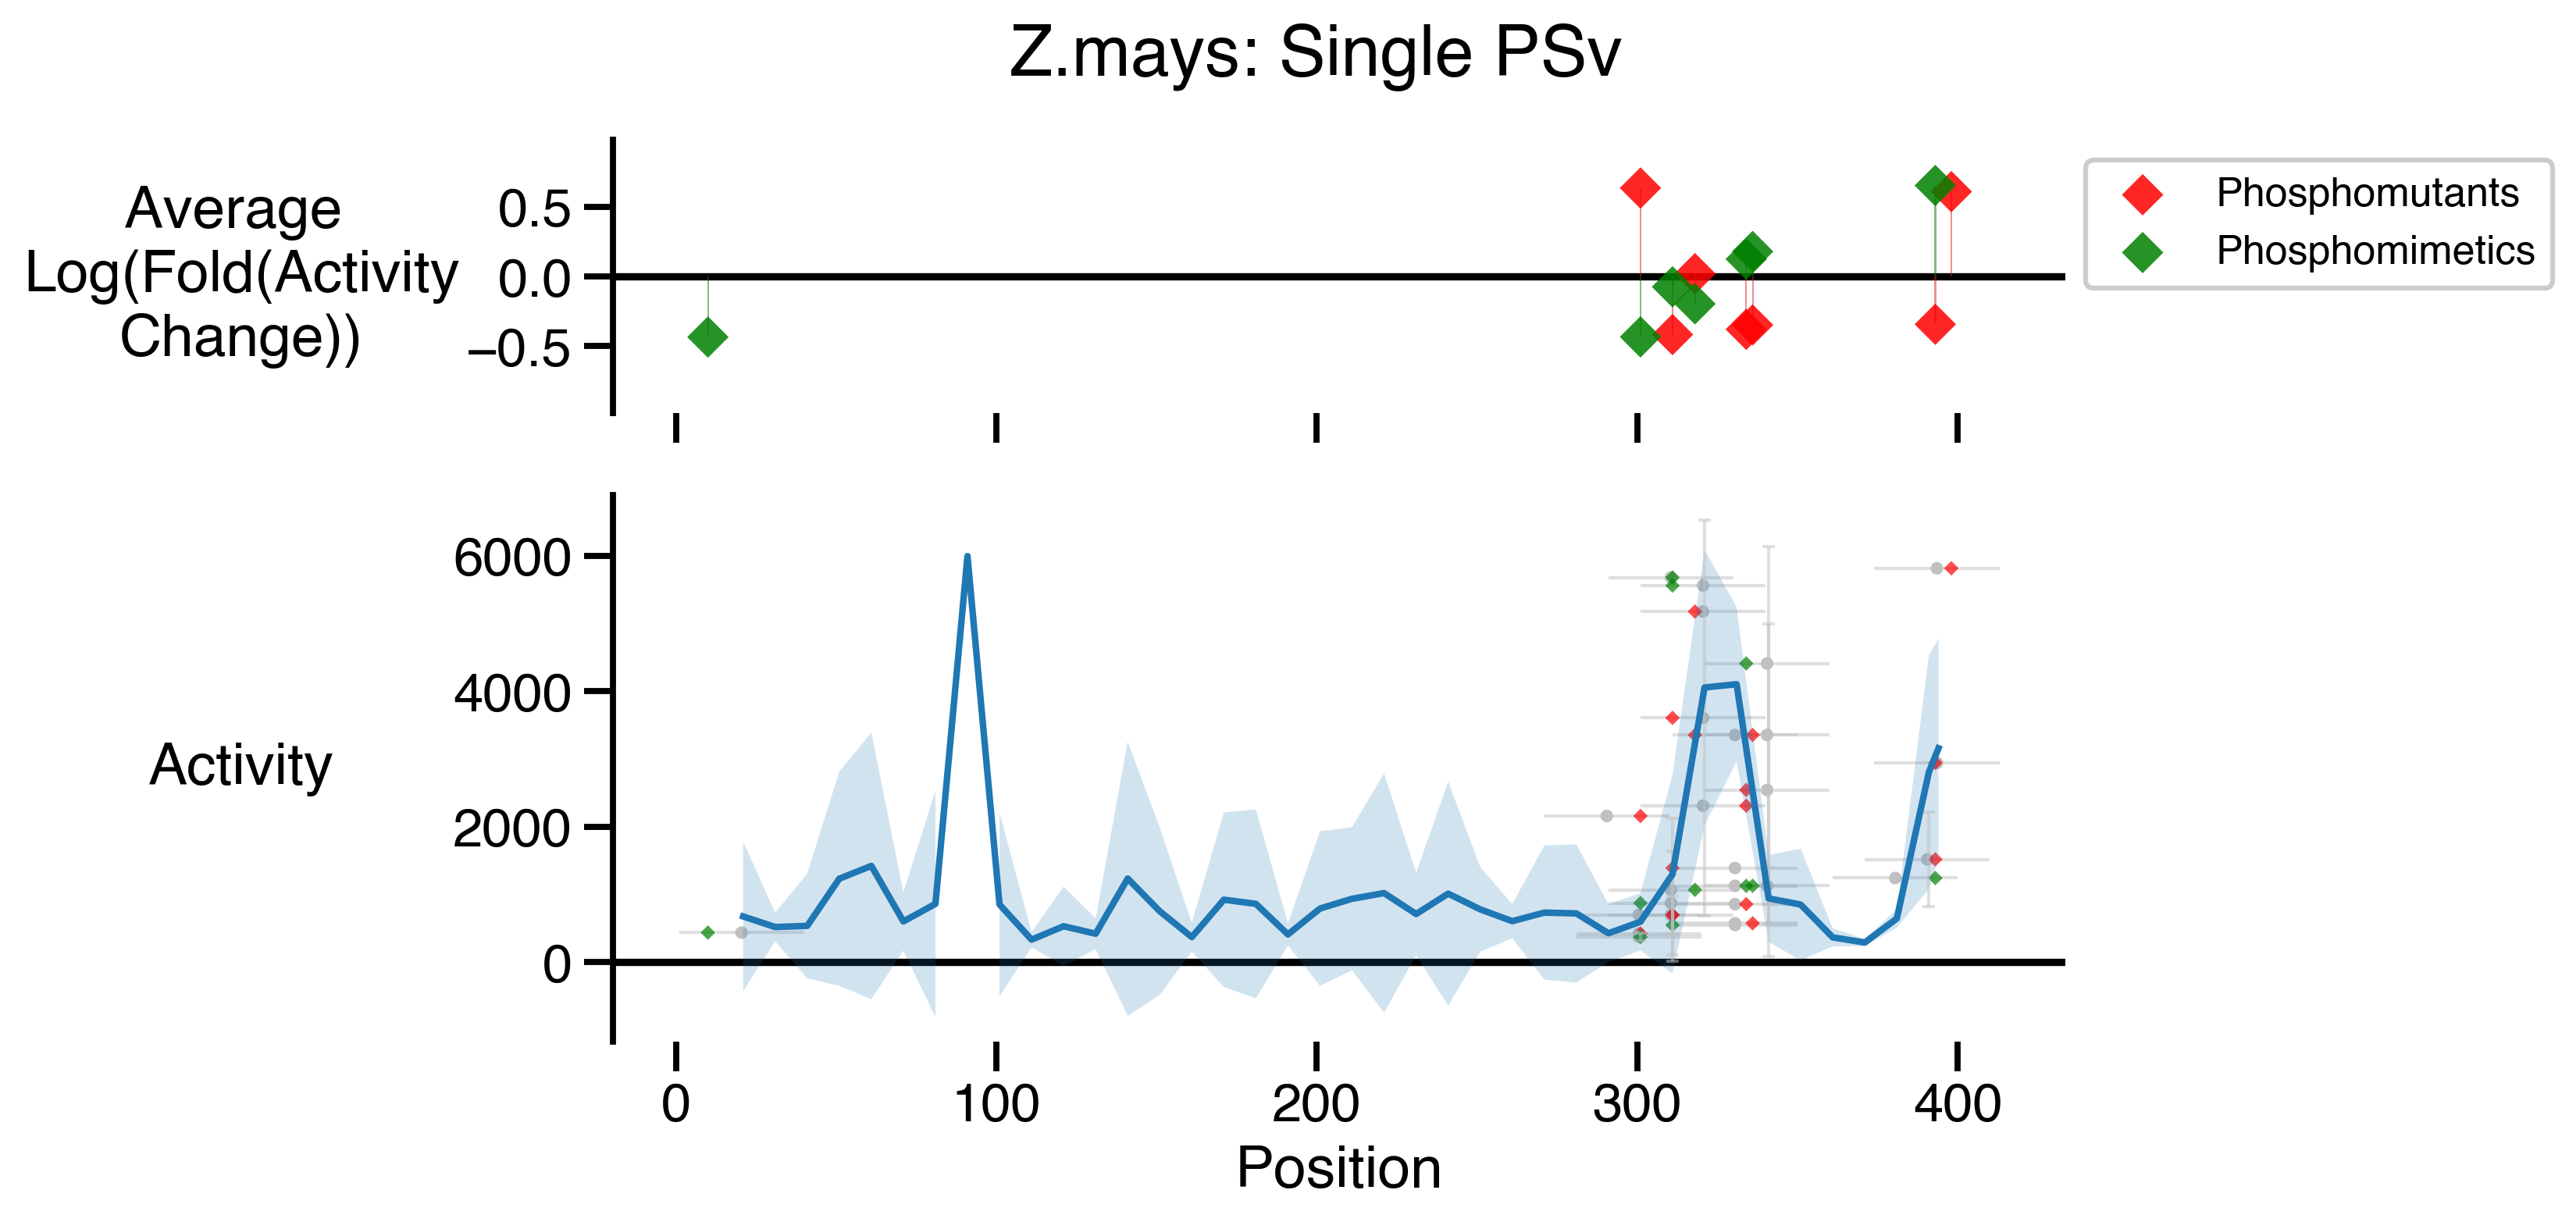

In [281]:
plot_single_PSv("BasicZeMa", title = "Z.mays")

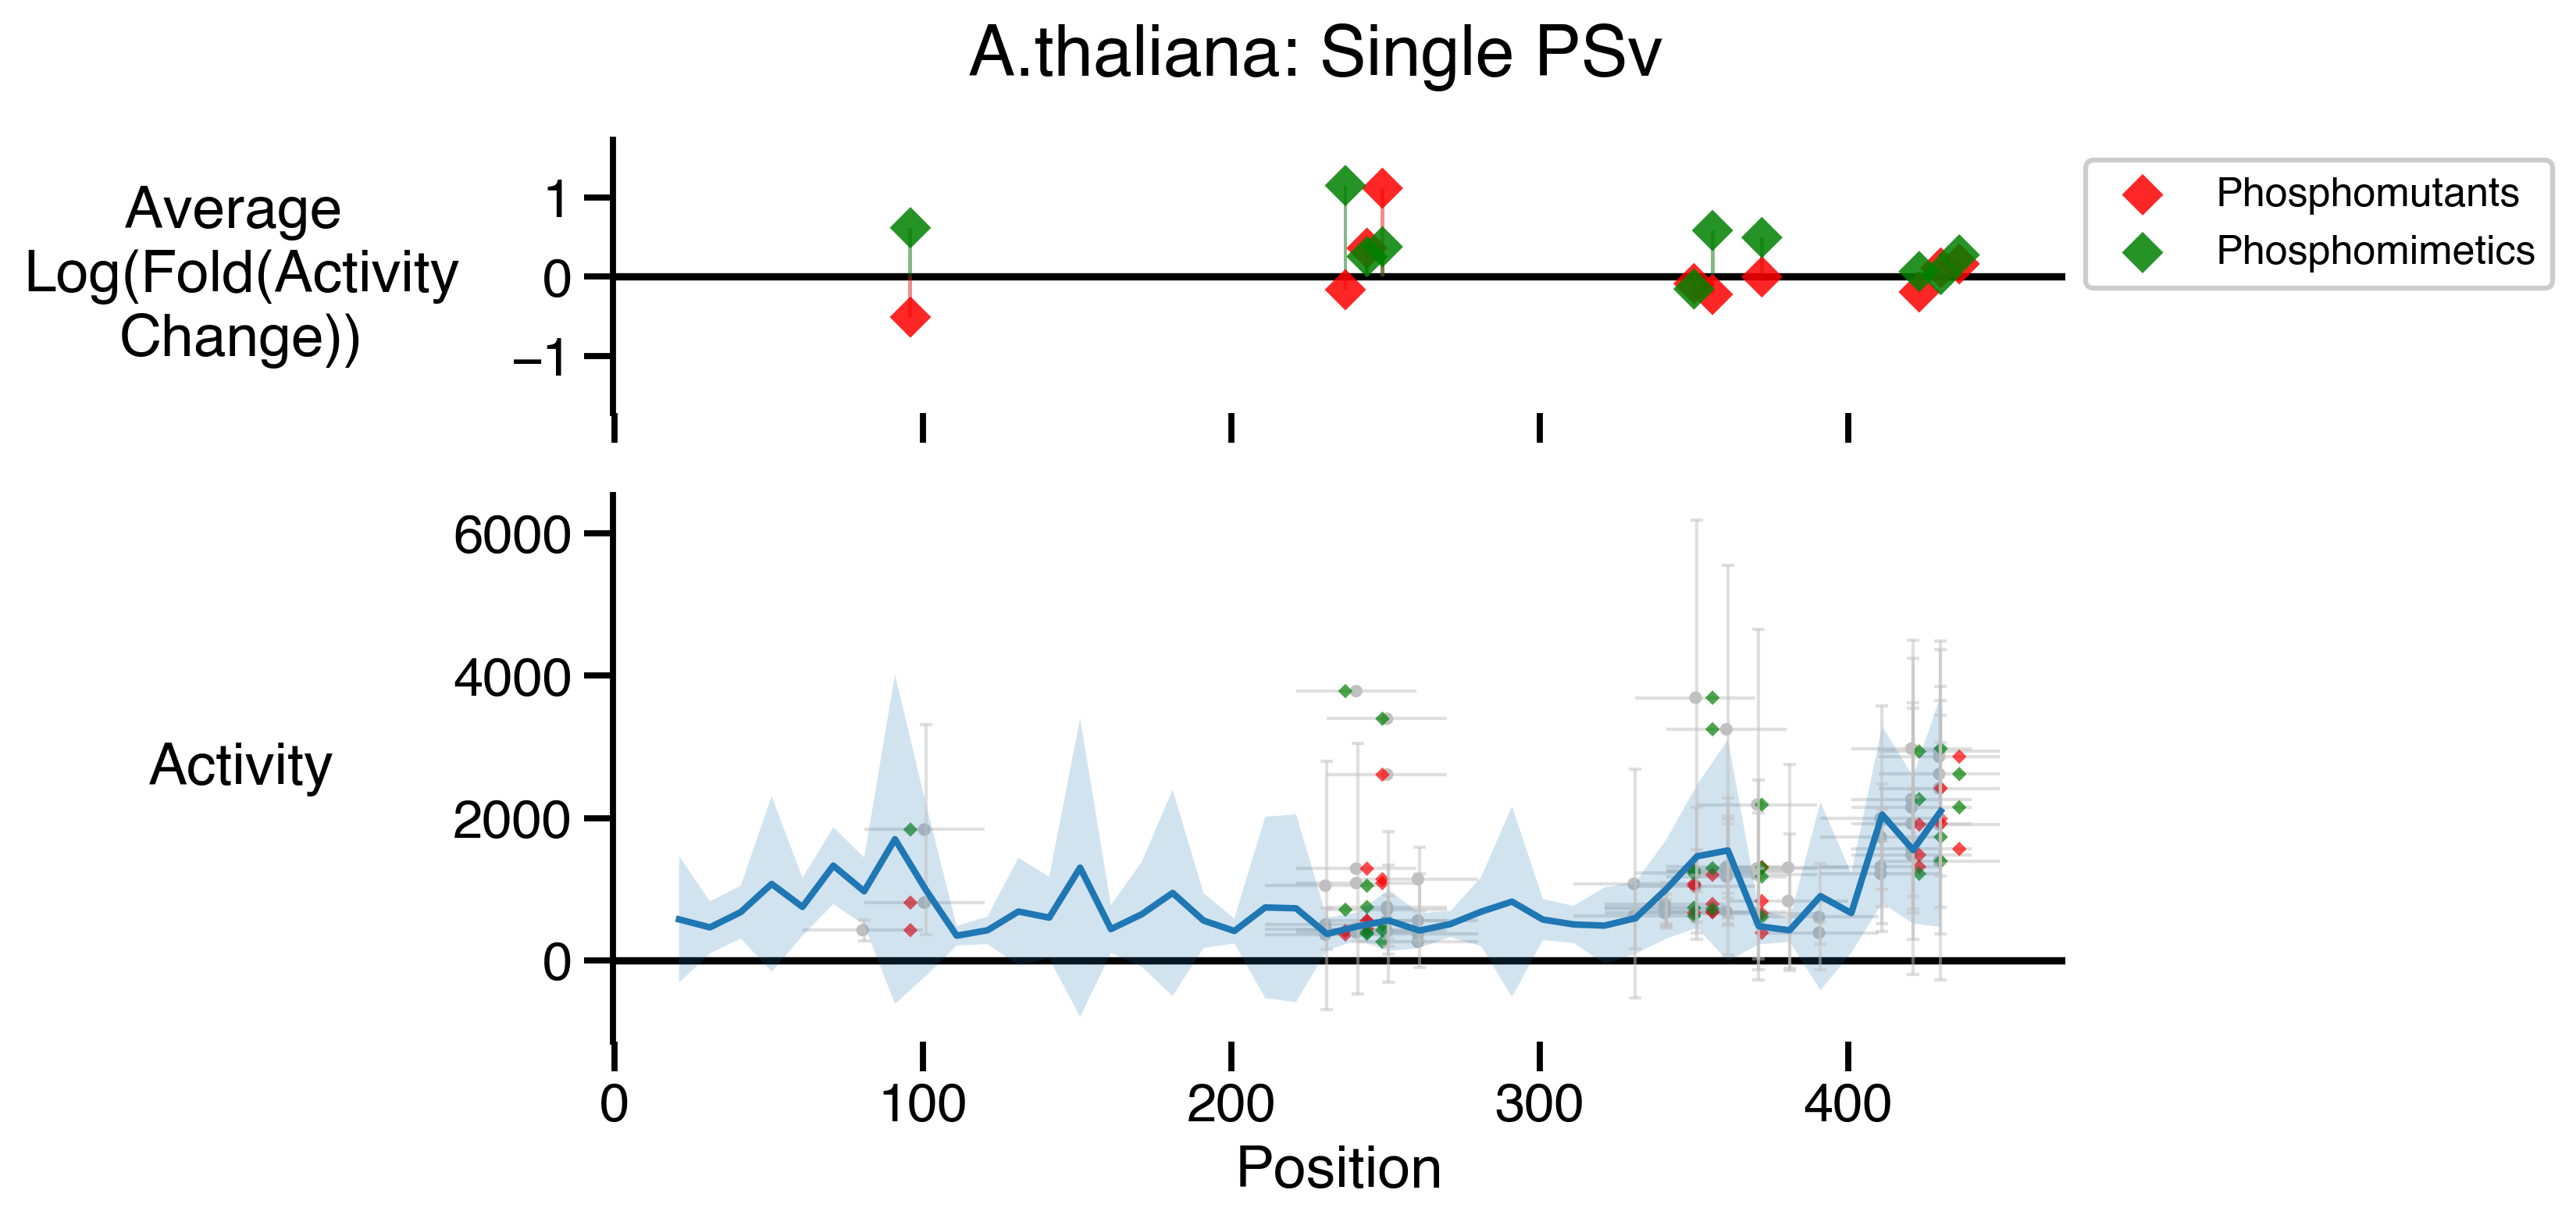

In [282]:
plot_single_PSv("BasicArTh", "A.thaliana")

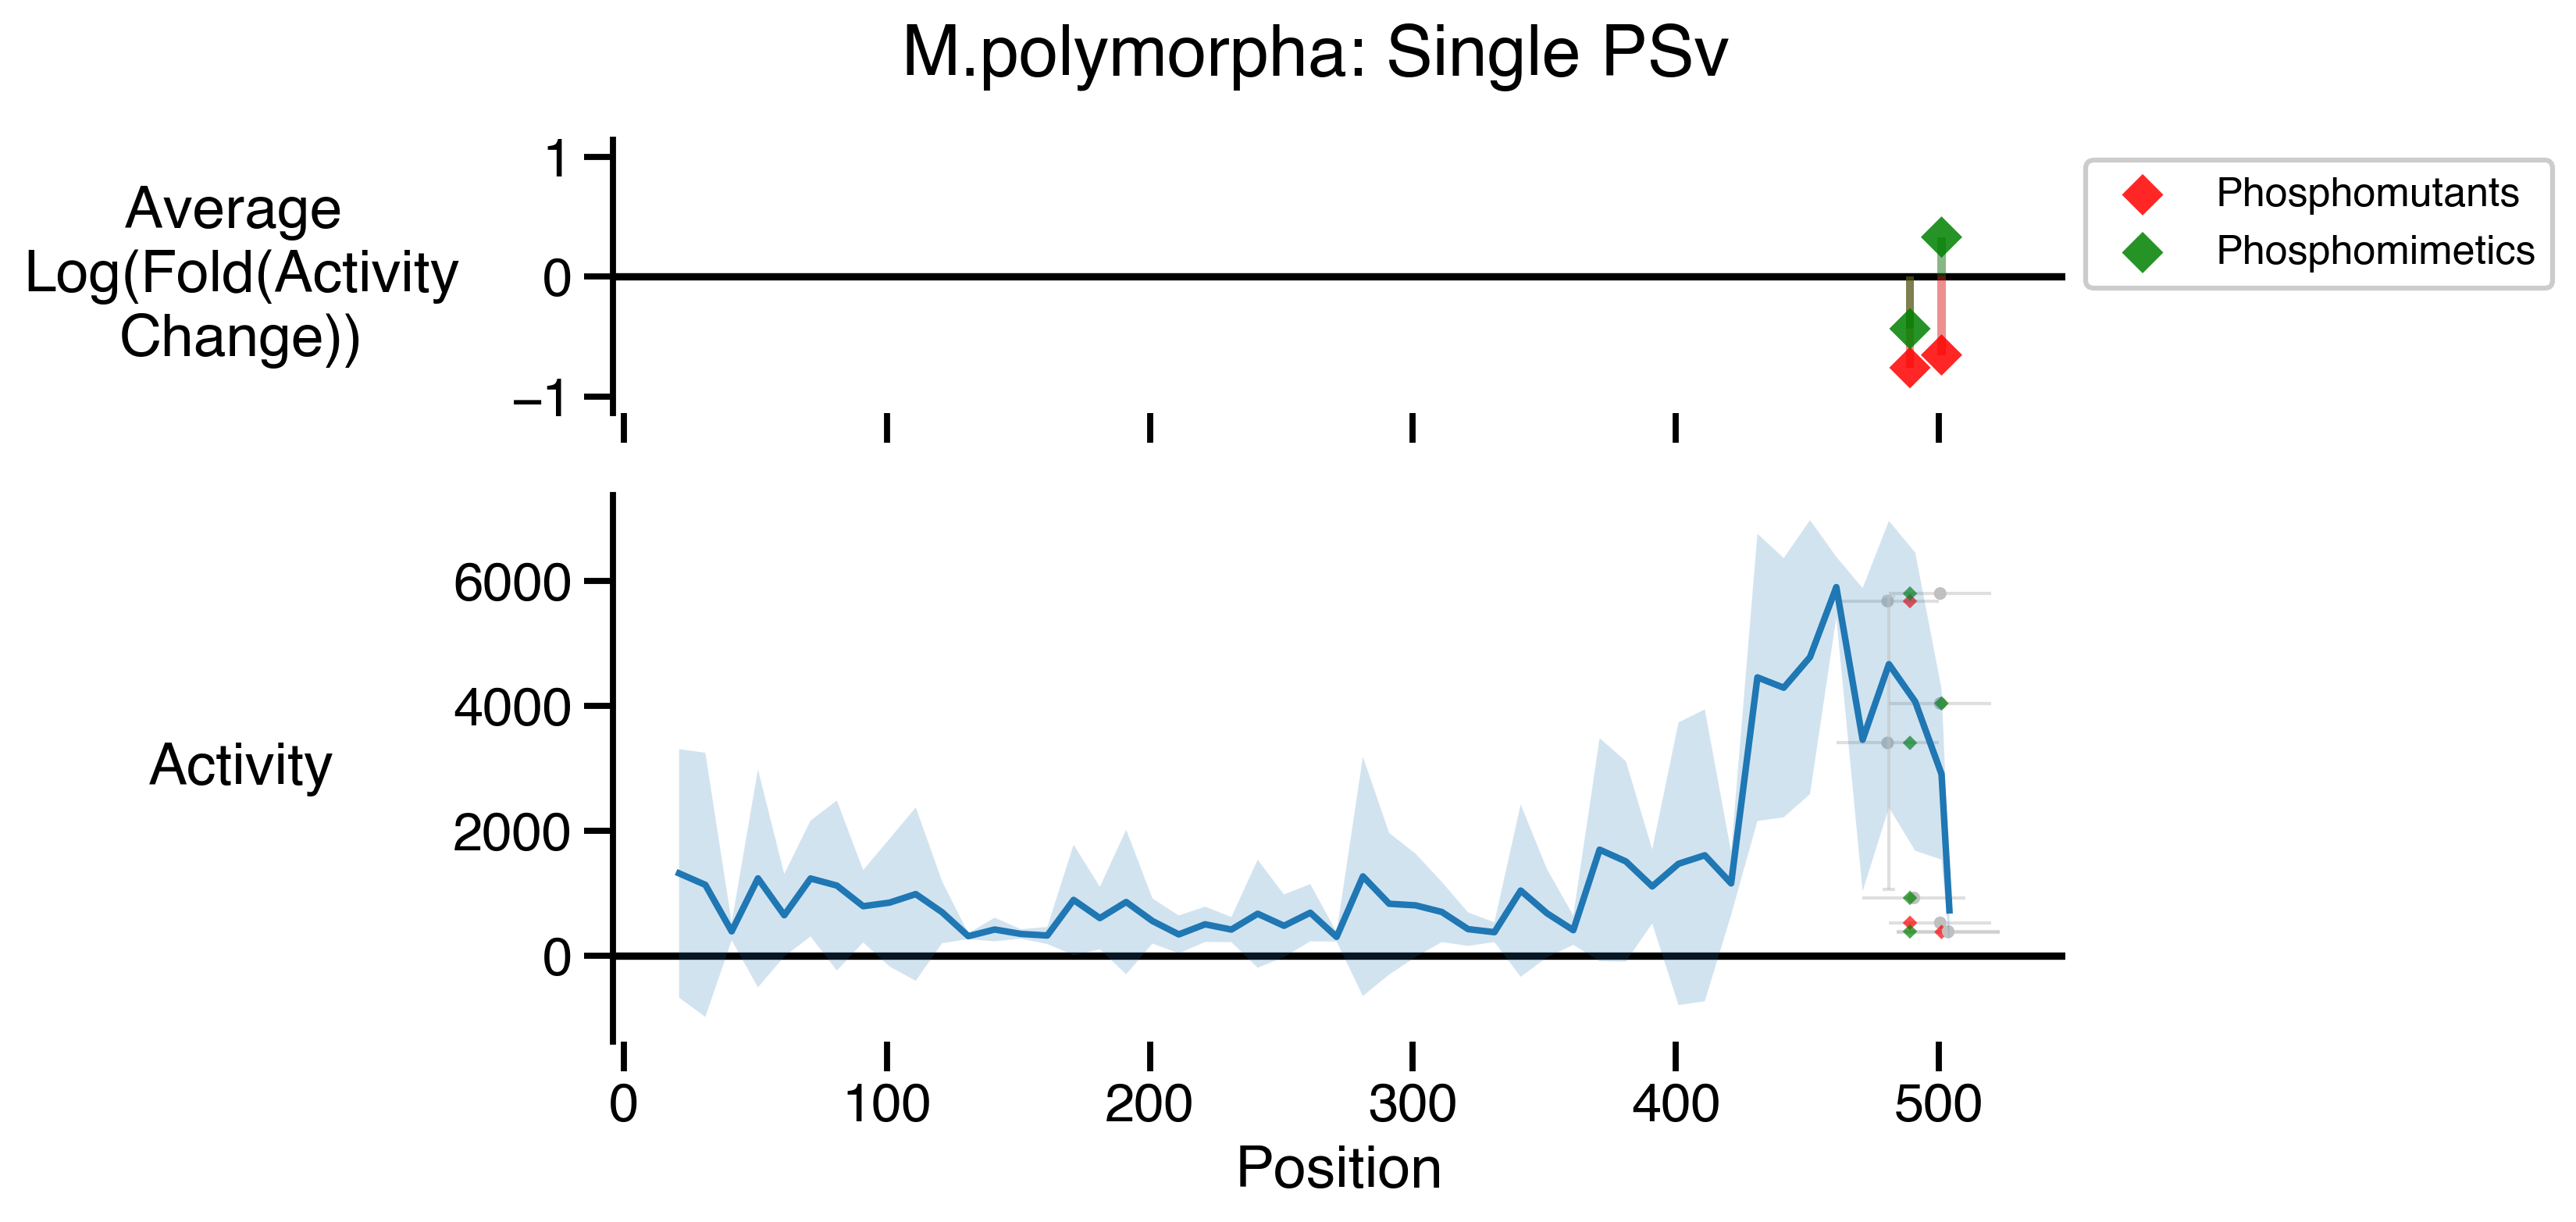

In [283]:
plot_single_PSv("BasicMaPo", "M.polymorpha")

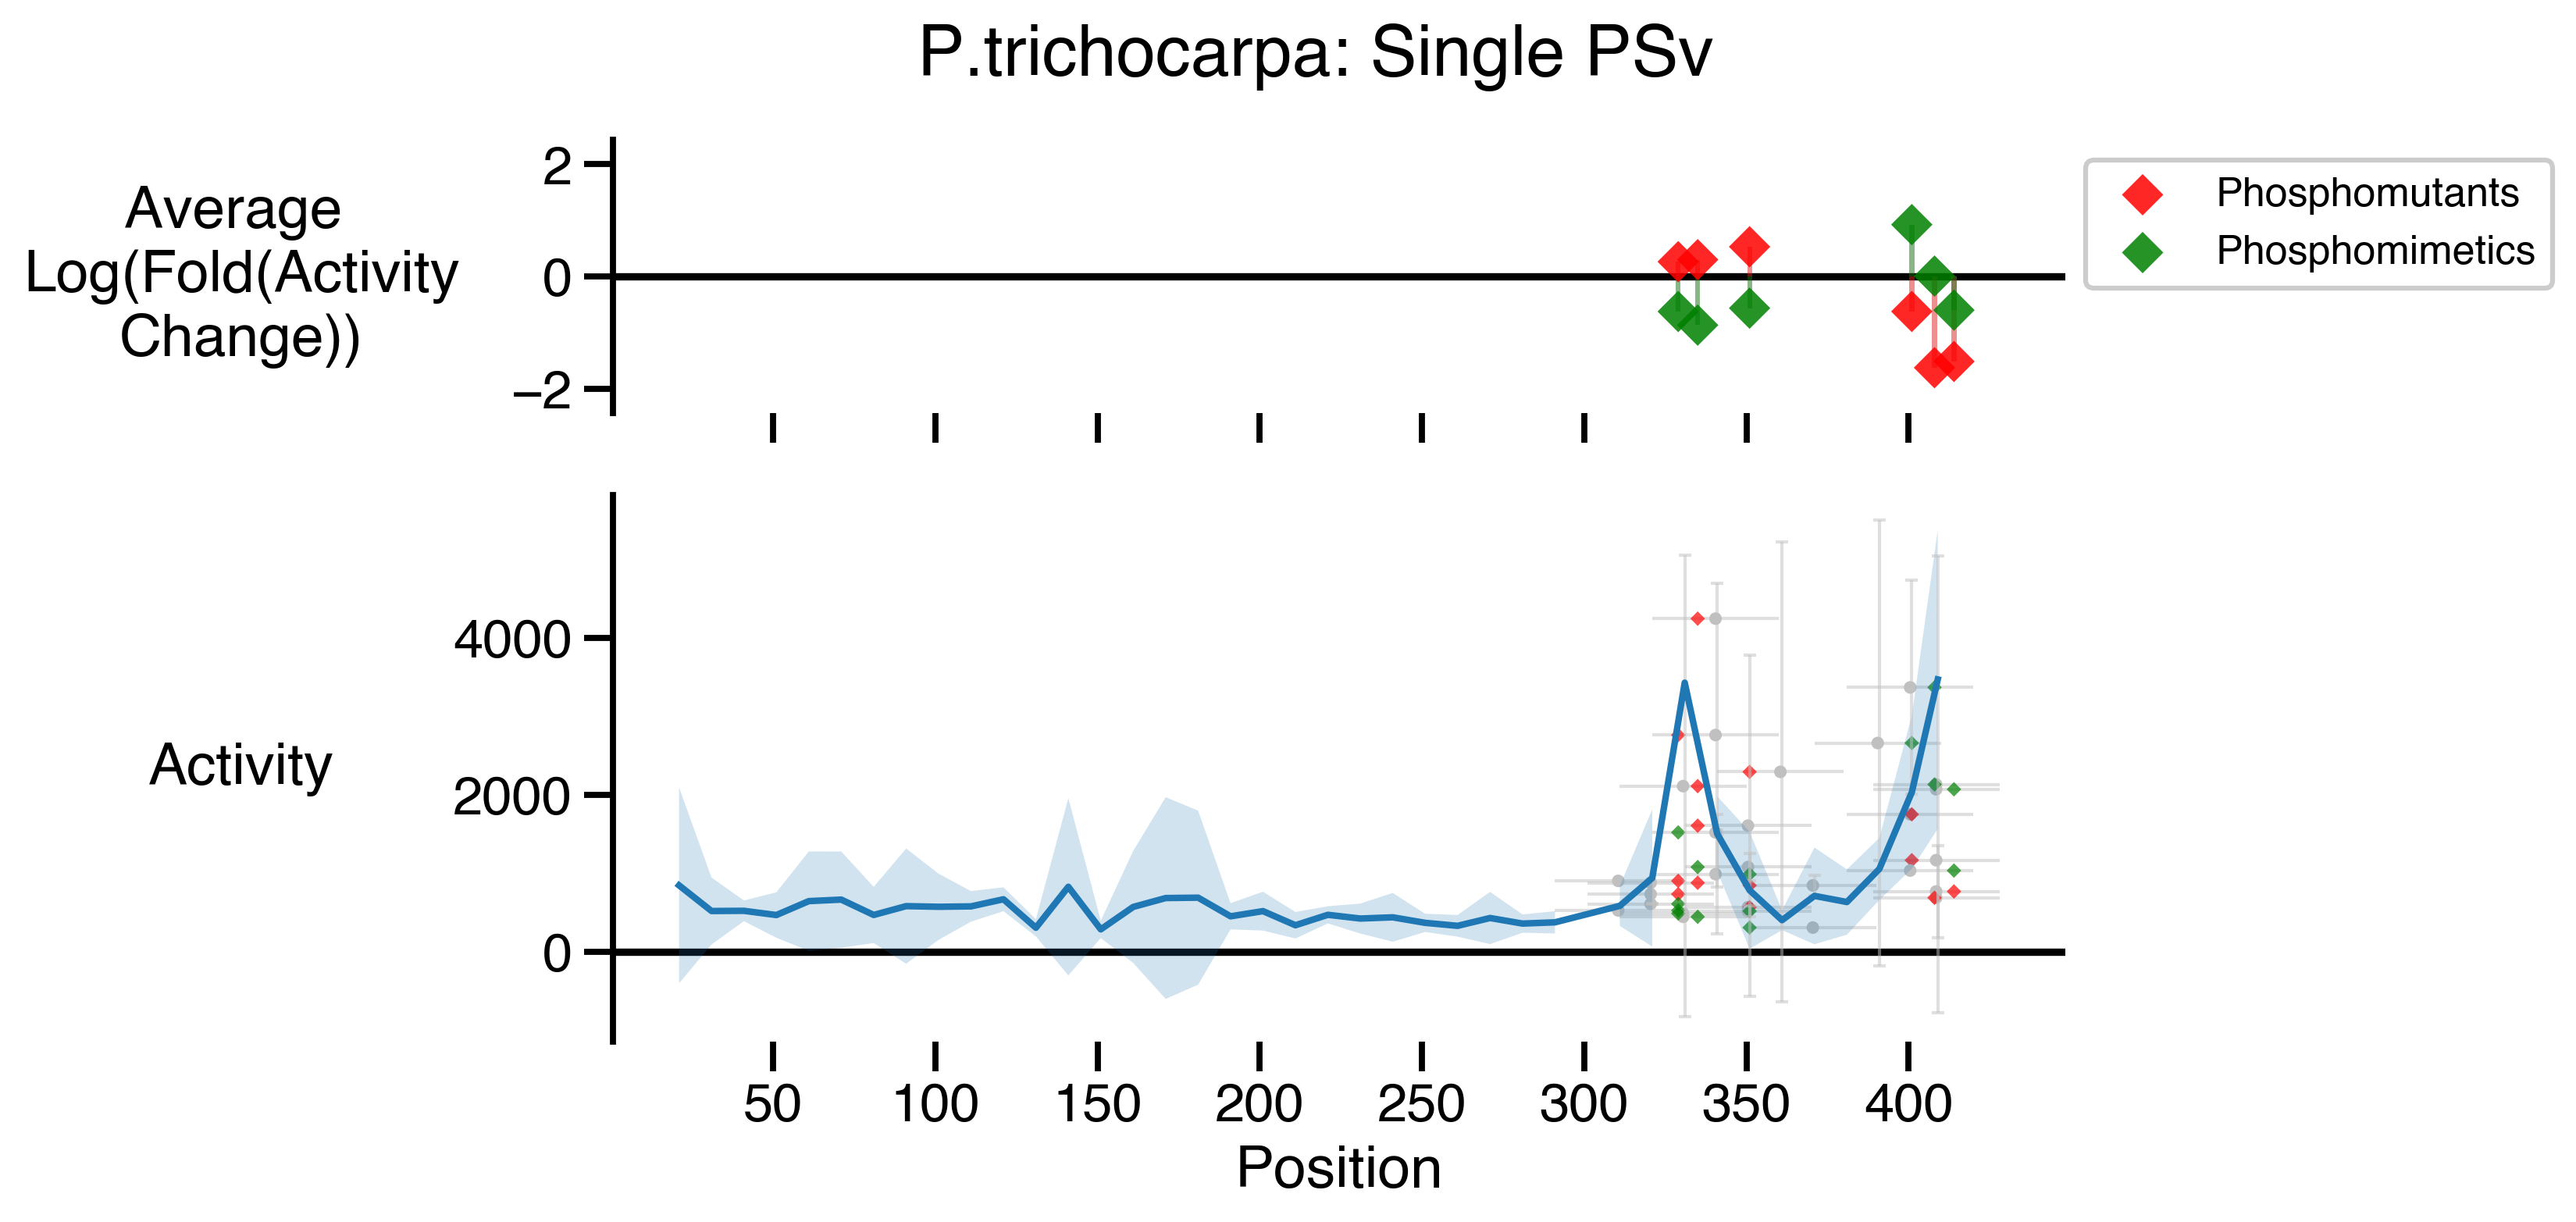

In [284]:
plot_single_PSv("BasicPoTr", "P.trichocarpa")

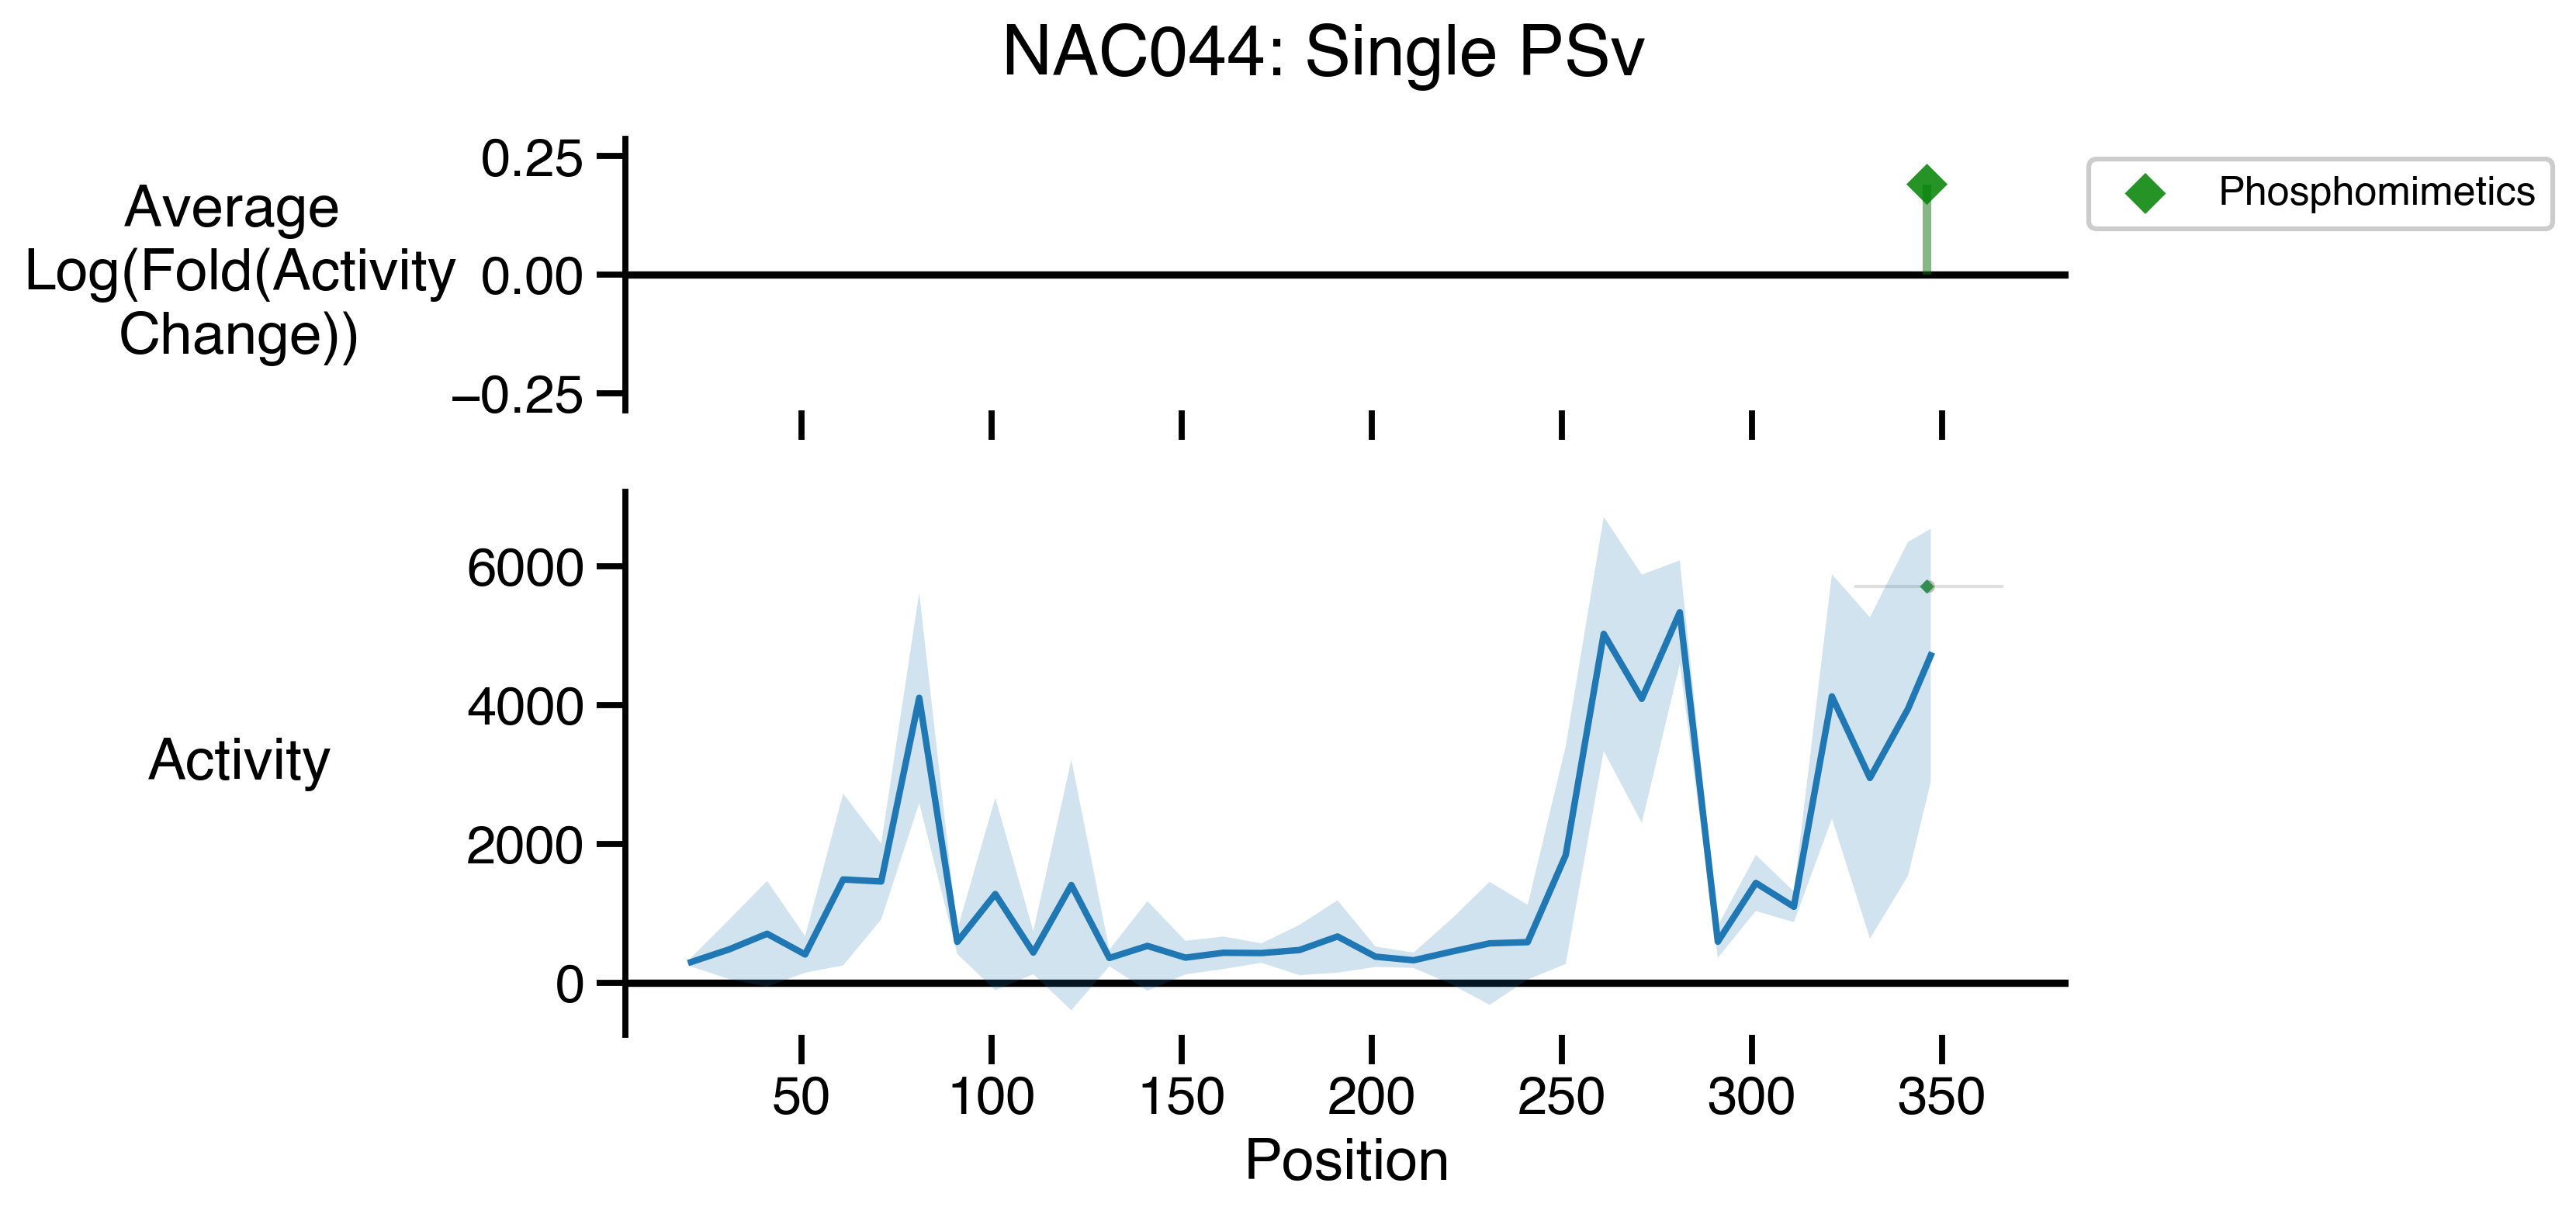

In [285]:
plot_single_PSv("Basic44", "NAC044")

In [234]:
Requested for NAC44, NAC085, P.trichocarpa, M.polymorpha, Z.mays, A. Thaliana, P53.

SyntaxError: invalid syntax (310916225.py, line 1)

In [62]:
wt_tiles = sog1_helpers.return_activities("BasicMaPo", pos_regex = "")
wt_tiles = wt_tiles[wt_tiles["Description"].str.contains("SingleD")]
wt_tiles

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
50,461,500,BasicMaPo.47_PSv_SingleD_T489D,MarchantiaPolymorphaSOG1_Lib1_full_pmim,GVDGLLDTPYHFNPHTDYFYTFDEYLLSDPPAIFPDLKLT,2951.0,3404.173130,2344.970666,3.0,1059.202463,5749.143796
54,471,510,BasicMaPo.48_PSv_SingleD_T489D,MarchantiaPolymorphaSOG1_Lib1_single_pmim_site_1,HFNPHTDYFYTFDEYLLSDPPAIFPDLKLTSQEASEVMRS,3042.0,922.037597,NaN,1.0,NaN,NaN
56,471,510,BasicMaPo.48_PSv_SingleD_S501D,MarchantiaPolymorphaSOG1_Lib1_single_pmim_site_2,HFNPHTDYFYTFDEYLLSTPPAIFPDLKLTDQEASEVMRS,NaN,NaN,NaN,NaN,NaN,NaN
60,481,520,BasicMaPo.49_PSv_SingleD_T489D,MarchantiaPolymorphaSOG1_Lib1_single_pmim_site_1,TFDEYLLSDPPAIFPDLKLTSQEASEVMRSIDPNDNSDSL,6416.0,5795.603397,NaN,1.0,NaN,NaN
62,481,520,BasicMaPo.49_PSv_SingleD_S501D,MarchantiaPolymorphaSOG1_Lib1_single_pmim_site_2,TFDEYLLSTPPAIFPDLKLTDQEASEVMRSIDPNDNSDSL,6417.0,4036.561151,NaN,1.0,NaN,NaN
66,484,523,BasicMaPo.50_PSv_SingleD_T489D,MarchantiaPolymorphaSOG1_Lib1_single_pmim_site_1,EYLLSDPPAIFPDLKLTSQEASEVMRSIDPNDNSDSLSST,2551.0,384.716097,NaN,1.0,NaN,NaN
68,484,523,BasicMaPo.50_PSv_SingleD_S501D,MarchantiaPolymorphaSOG1_Lib1_single_pmim_site_2,EYLLSTPPAIFPDLKLTDQEASEVMRSIDPNDNSDSLSST,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:


# Plot part 1

sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_A", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "red", width = 0.25)



sns.barplot(data=pos_avgs, 
                x="var", 
                y="log_activ_fold_change_D", 
                legend=False, 
                alpha=0.5, 
                edgecolor = "none", 
                native_scale = True, ax = axs[0], color = "green", width = 0.25)

sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_A", color = "red", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomutants")
sns.scatterplot(data = pos_avgs, x = "var", y = "log_activ_fold_change_D", color = "green", marker = "D", lw = 1, edgecolor = 'none', ax = axs[0], 
                label = "Phosphomimetics")

#axs[0].legend(bbox_to_anchor = (1, 1), fontsize = "small")
axs[0].legend(loc = "upper left", fontsize = "x-small", framealpha = 1)

#axs[0].text(x = 0, y = 1, s = "Phosphomutants ($\\rightarrow$A)", color = "red")

# Plot part 2
sog1_helpers.plot_all_tiles(PSv_conf2sA_STYA_vs_basic, activity_col + "_var", ax=axs[1], color='silver')
sns.scatterplot(data=PSv_conf2sA_STYA_vs_basic, 
                x="var", 
                y=activity_col + "_var", 
                color="red", 
                legend=False, 
                alpha=0.7, ax=axs[1], marker = "D", edgecolor = "none", s = 10)

sog1_helpers.plot_all_tiles(PSv_conf2sD_vs_basic, activity_col + "_var", ax=axs[1], color='silver')
sns.scatterplot(data=PSv_conf2sD_vs_basic, 
                x="var", 
                y=activity_col + "_var", 
                color="green", 
                legend=False, 
                alpha=0.7, ax=axs[1], marker = "D", edgecolor = "none", s = 10)

sns.lineplot(data=BasicArTh, x="mid", y=activity_col, label="WT Tiles", lw=2, ax=axs[1], legend = False)


axs[0].axhline(0, color = "gray", zorder = 0, linestyle = "--")
axs[0].set_ylabel("Average \nLog(Fold(Activity\nChange))", rotation = 0, labelpad = 30, va = 'center')
axs[0].set_ylim(-0.7, 1.3)

axs[1].set_xlim(1, 449)
axs[1].set_ylabel("Activity", rotation = 0, labelpad = 30, va = 'center')
axs[1].set_xlabel("Position")

sns.despine()

plt.suptitle("Sog1: Single Confirmed Phosphosite Variants")

fig.align_ylabels(axs)
